Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50
Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45


Early stopping at iteration 51 - found feasible solution
Solution stored in memory. Memory size: 1

Algorithm Contributions:
OOA: 18.4%
KHA: 60.8%
SHO: 20.9%


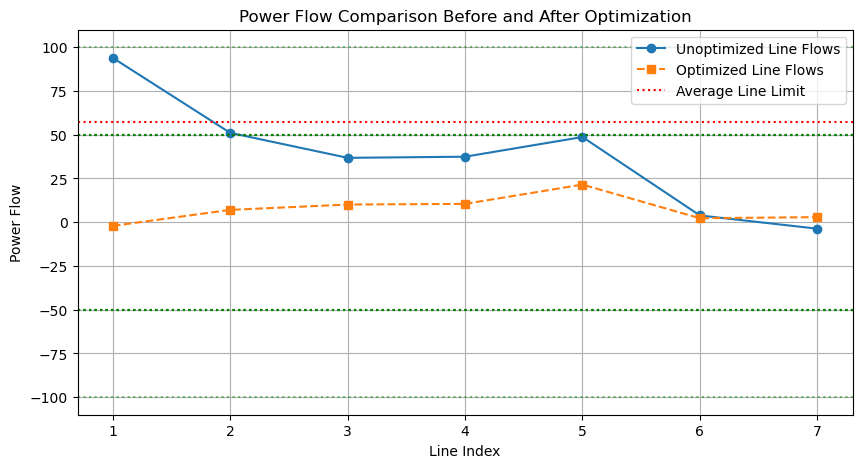

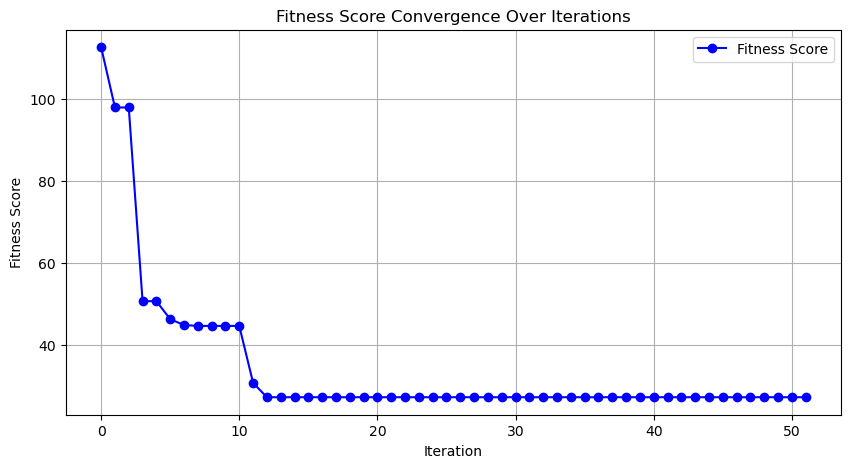

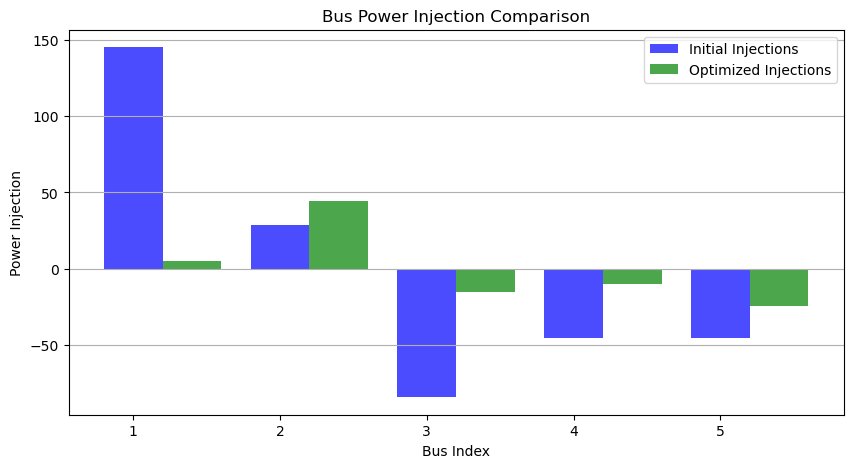


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[  4.9617706 ]
 [ 44.19287997]
 [-14.89103938]
 [ -9.84815738]
 [-24.41545381]]

Sum of Optimized Power Injections (Should be 0):  3.552713678800501e-15

Resultant Line Flows After Optimization (7x1):
 [[-2.09146607]
 [ 7.05323666]
 [10.10522016]
 [10.48204628]
 [21.50877574]
 [ 2.26936281]
 [ 2.90667807]]

All line constraints satisfied!

Total Line Power Flow Before Optimization: 275.478
Total Line Power Flow After Opt

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        
    def optimize(self, B, iterations=200, population_size=20):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution)
                if fitness < best_fitness:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                print(f"Early stopping at iteration {iteration} - found feasible solution")
                break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B"""
        random_solution = B.copy() + np.random.uniform(-0.5, 0.5, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution):
        """Calculate fitness with penalty for constraint violations"""
        C = np.dot(self.A, solution)
        # Penalty for line limit violations
        penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        # Fitness based on line flow magnitude and violations
        return np.linalg.norm(C) + penalty * 10
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all constraints)"""
        C = np.dot(self.A, solution)
        return np.all(abs(C.flatten()) <= self.line_limits)
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            if similarity < best_similarity:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution) < self._calculate_fitness(random_solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200):
    optimizer = HybridPowerFlowOptimizer(A, line_limits)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
    plt.xlabel('Iteration')
    plt.ylabel('Fitness Score')
    plt.title('Fitness Score Convergence Over Iterations')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # Run optimization
    B_optimized, fitness_history, C_optimized, C_unoptimized = optimize_power_flow(A, B, line_limits)
    
    # Visualize and report results
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history)

Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50
Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45
Enter priority for minimizing changes (0.1-0.9, higher = more emphasis on minimal changes):  0.85


Minimizing changes: Step 0, Improvement: 2.00%
Minimizing changes: Step 10, Improvement: 18.11%
Minimizing changes: Step 20, Improvement: 28.74%
Minimizing changes: Step 30, Improvement: 35.42%
Minimizing changes: Step 40, Improvement: 39.07%
Solution stored in memory. Memory size: 1

Algorithm Contributions:
OOA: 37.0%
KHA: 34.8%
SHO: 28.1%


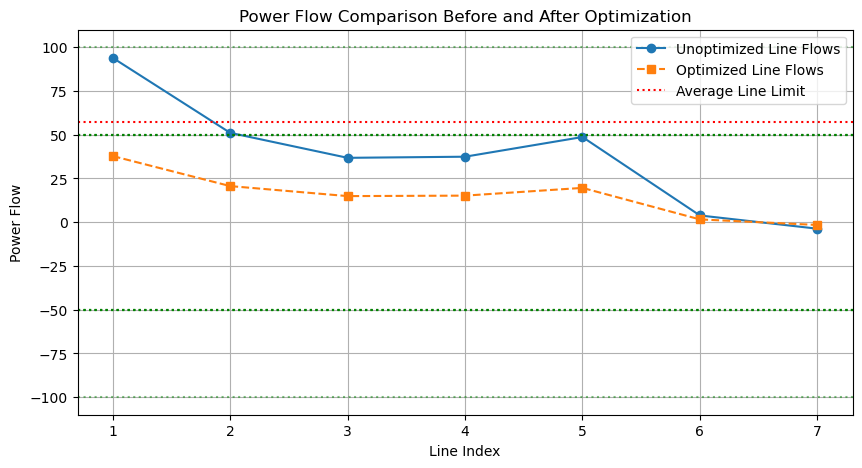

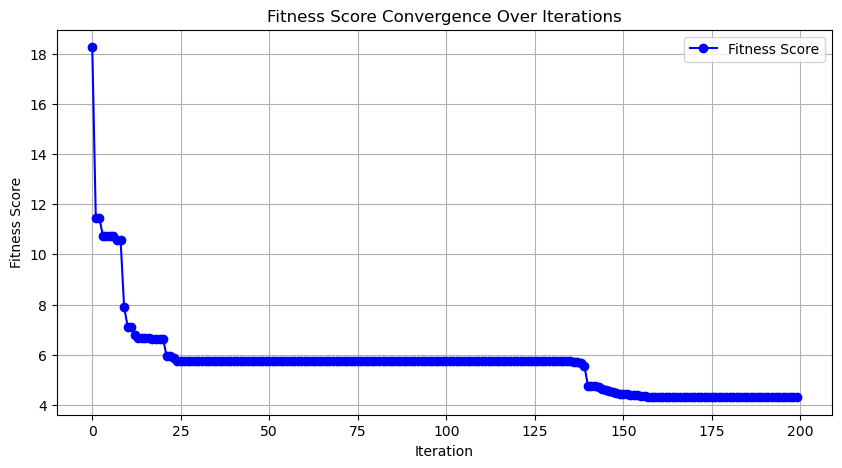

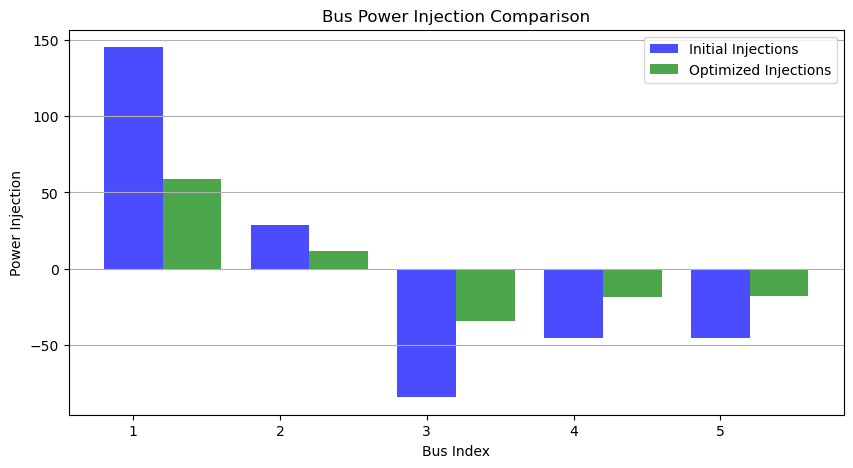

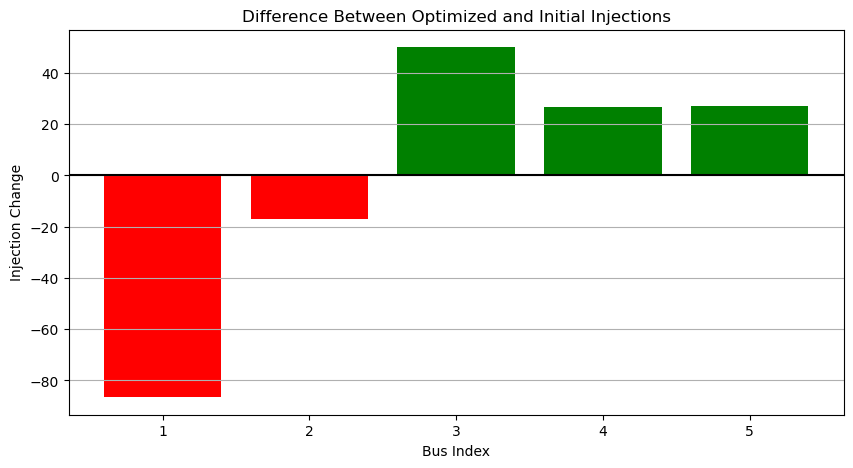


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[ 58.45519455]
 [ 11.92720419]
 [-33.95322195]
 [-18.38023055]
 [-18.04894623]]

Sum of Optimized Power Injections (Should be 0):  0.0

Resultant Line Flows After Optimization (7x1):
 [[37.80889616]
 [20.64629839]
 [14.92568644]
 [15.19295715]
 [19.61785446]
 [ 1.61472225]
 [-1.56890823]]

Changes to Power Injections:
Absolute Changes: [86.54480545 17.07279581 50.04677805 26.61976945 26.95105377]
Percentage Changes: [59.

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        
    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        
        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)
                if fitness < best_fitness:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                if deviation < 0.1:  # Stop if changes are less than 10%
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Minimize changes to original injections while keeping line constraints satisfied
        best_solution = self._minimize_changes(best_solution, B)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)
        
        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)
            
            # Ensure power balance
            new_solution -= np.mean(new_solution)
            
            # Check if still feasible
            if self._is_feasible(new_solution):
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%")
        
        return best_solution
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B"""
        # Use smaller perturbation to stay closer to original injections
        random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean() 
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations and deviation from original B
        
        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        
        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)
        
        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all constraints)"""
        C = np.dot(self.A, solution)
        return np.all(abs(C.flatten()) <= self.line_limits)
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            if similarity < best_similarity:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7):
    optimizer = HybridPowerFlowOptimizer(A, line_limits)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
    plt.xlabel('Iteration')
    plt.ylabel('Fitness Score')
    plt.title('Fitness Score Convergence Over Iterations')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("Enter priority for minimizing changes (0.1-0.9, higher = more emphasis on minimal changes): "))
    
    # Run optimization
    B_optimized, fitness_history, C_optimized, C_unoptimized = optimize_power_flow(A, B, line_limits, alpha=alpha)
    
    # Visualize and report results
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history)

Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50
Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45
Enter priority for minimizing changes (0.1-0.9, higher = more emphasis on minimal changes):  0.9
Enter maximum allowed sum of differences (recommended: 4.0):  4


Iteration 120: Sum of differences = 3.9834
Iteration 160: Sum of differences = 3.9932

Algorithm Contributions:
OOA: 35.9%
KHA: 37.5%
SHO: 26.6%

Final sum of differences: 4.0000 (max allowed: 4.0)


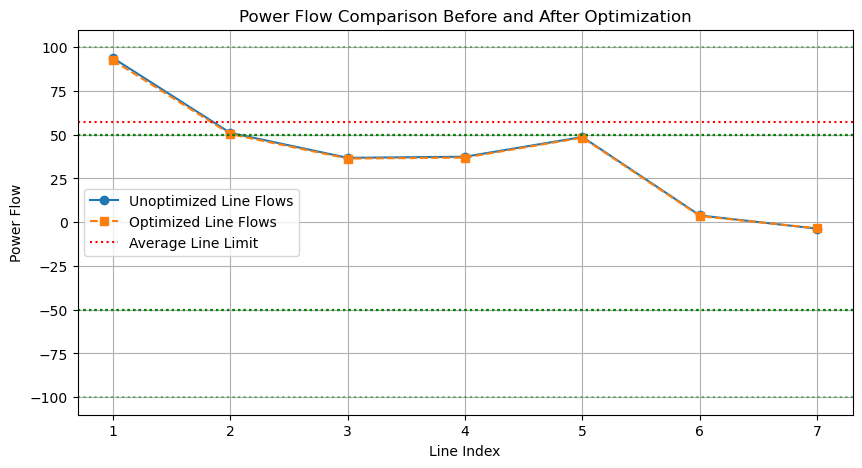

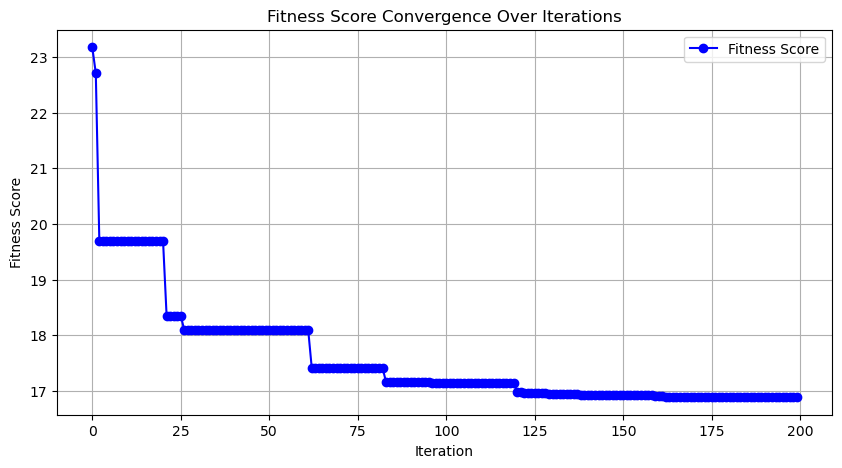

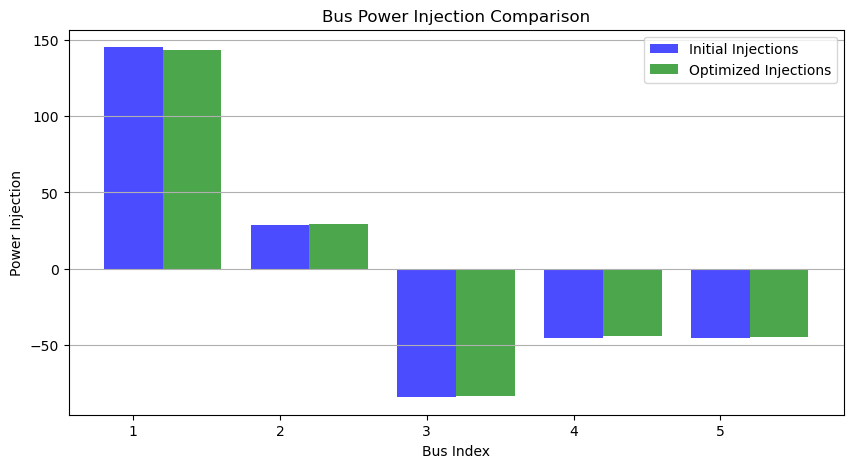

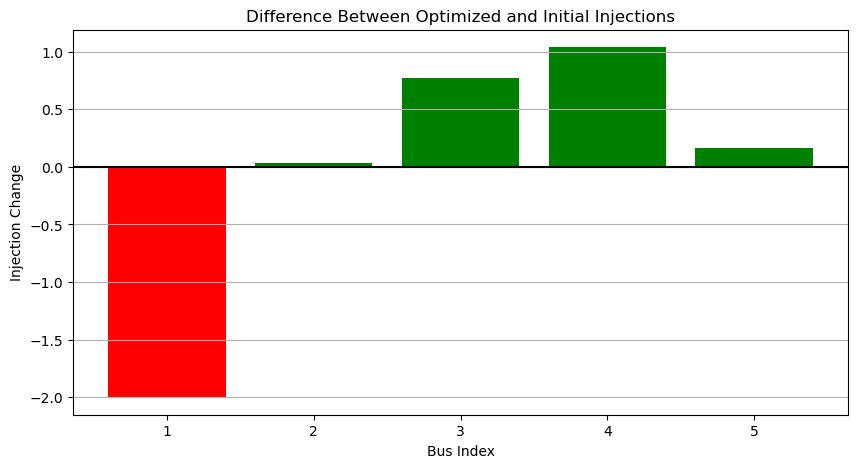


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[143.00000013]
 [ 29.03253698]
 [-83.23104975]
 [-43.96137477]
 [-44.84011259]]

Sum of Optimized Power Injections (Should be 0):  -7.105427357601002e-15

Resultant Line Flows After Optimization (7x1):
 [[92.58863608]
 [50.41136405]
 [36.35295846]
 [36.93563403]
 [48.33351642]
 [ 3.52345677]
 [-3.49340383]]

Changes to Power Injections:
Absolute Changes: [1.99999987 0.03253698 0.76895025 1.03862523 0.15988741]
Sum of Abs

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        
    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        
        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)
                
                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    
                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.4f}")
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal and below sum difference threshold
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:  
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.4f} (max allowed: {self.max_sum_diff})")
                    break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.4f} (max allowed: {self.max_sum_diff})")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)
        
        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)
            
            # Ensure power balance
            new_solution -= np.mean(new_solution)
            
            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.4f}")
        
        return best_solution
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B that respects sum diff constraint"""
        max_attempts = 10
        
        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean() 
            random_solution -= np.mean(random_solution)  # Ensure power balance
            
            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution
        
        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint
        
        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        
        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)
        
        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10
        
        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all constraints including sum diff)"""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        line_constraints_met = np.all(abs(C.flatten()) <= self.line_limits)
        
        # Check sum difference constraint
        sum_diff = np.sum(np.abs(solution - solution))  # This is comparing to itself, which is wrong. Should be original_B
        # But since we don't have access to original_B here, we'll check this in the main optimize loop
        
        return line_constraints_met
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            
            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))
            
            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
    plt.xlabel('Iteration')
    plt.ylabel('Fitness Score')
    plt.title('Fitness Score Convergence Over Iterations')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.4f} (Constraint: < {max_sum_diff})")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check sum difference constraint
    if sum_diff > max_sum_diff:
        print(f"\nWARNING: Sum of differences ({sum_diff:.4f}) exceeds constraint ({max_sum_diff})")
    else:
        print(f"\nSum difference constraint satisfied: {sum_diff:.4f} < {max_sum_diff}")

    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("Enter priority for minimizing changes (0.1-0.9, higher = more emphasis on minimal changes): "))
    
    # User input for maximum sum difference constraint (default 4.0)
    max_sum_diff = float(input("Enter maximum allowed sum of differences (recommended: 4.0): "))
    
    # Run optimization
    B_optimized, fitness_history, C_optimized, C_unoptimized = optimize_power_flow(A, B, line_limits, alpha=alpha, max_sum_diff=max_sum_diff)
    
    # Visualize and report results
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=max_sum_diff)

Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50
Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45
Enter priority for minimizing changes (0.1-0.9, higher = more emphasis on minimal changes):  0.9
Enter maximum allowed sum of differences (recommended: 4.0):  4



Algorithm Contributions:
OOA: 34.8%
KHA: 36.1%
SHO: 29.1%

Final sum of differences: 4.0000 (max allowed: 4.0)


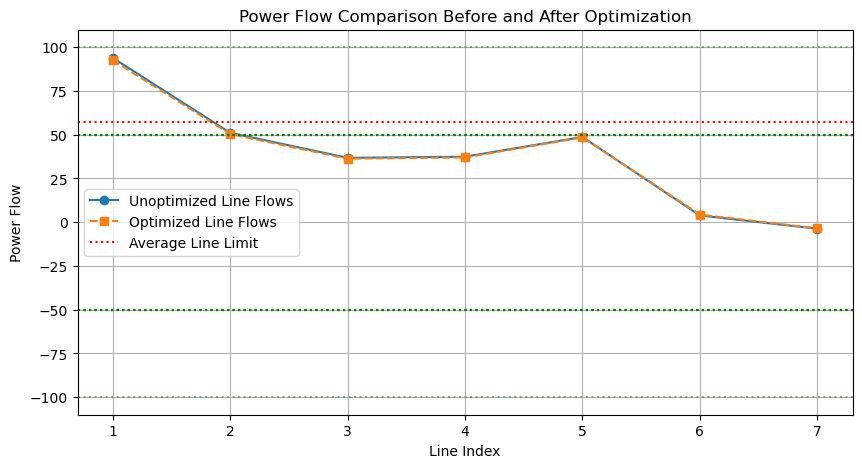

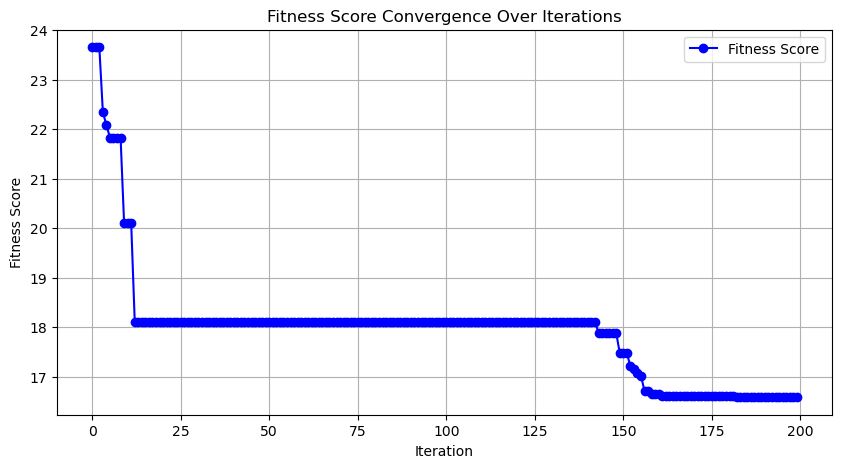

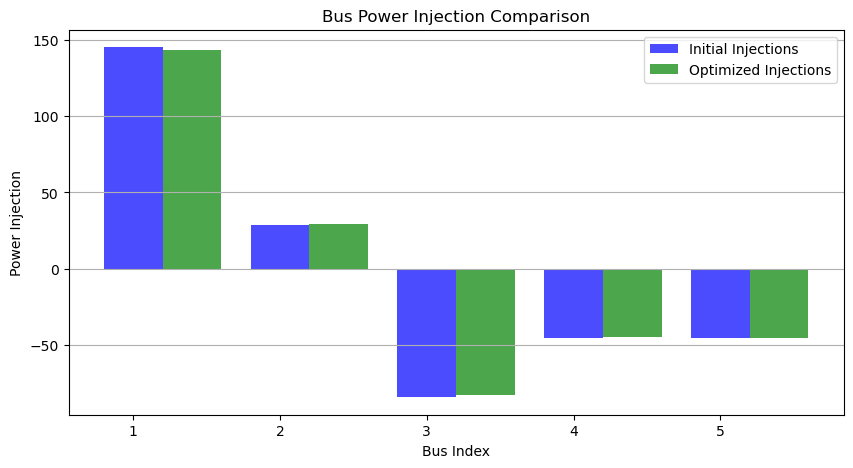

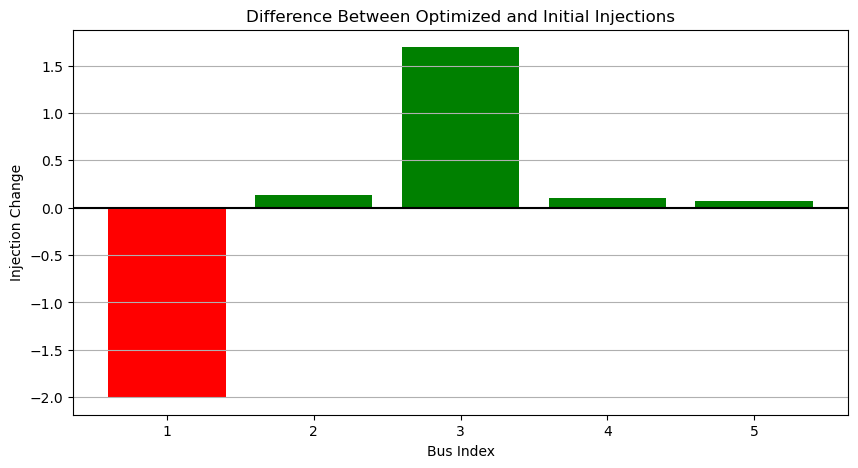


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[143.00001509]
 [ 29.13859131]
 [-82.30658188]
 [-44.90157376]
 [-44.93045076]]

Sum of Optimized Power Injections (Should be 0):  -7.105427357601002e-15

Resultant Line Flows After Optimization (7x1):
 [[92.62045374]
 [50.37956135]
 [36.29996155]
 [37.02267453]
 [48.43723272]
 [ 4.36313407]
 [-3.50678196]]

Changes to Power Injections:
Absolute Changes: [1.99998491 0.13859131 1.69341812 0.09842624 0.06954924]
Sum of Abs

In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        
    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        
        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)
                
                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    
                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.4f}")
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal and below sum difference threshold
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:  
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.4f} (max allowed: {self.max_sum_diff})")
                    break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.4f} (max allowed: {self.max_sum_diff})")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)
        
        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)
            
            # Ensure power balance
            new_solution -= np.mean(new_solution)
            
            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.4f}")
        
        return best_solution
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B that respects sum diff constraint"""
        max_attempts = 10
        
        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean() 
            random_solution -= np.mean(random_solution)  # Ensure power balance
            
            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution
        
        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint
        
        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        
        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)
        
        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10
        
        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all constraints including sum diff)"""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        line_constraints_met = np.all(abs(C.flatten()) <= self.line_limits)
        
        # Check sum difference constraint
        sum_diff = np.sum(np.abs(solution - solution))  # This is comparing to itself, which is wrong. Should be original_B
        # But since we don't have access to original_B here, we'll check this in the main optimize loop
        
        return line_constraints_met
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            
            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))
            
            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
    plt.xlabel('Iteration')
    plt.ylabel('Fitness Score')
    plt.title('Fitness Score Convergence Over Iterations')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.4f} (Constraint: < {max_sum_diff})")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check sum difference constraint
    if sum_diff > max_sum_diff:
        print(f"\nWARNING: Sum of differences ({sum_diff:.4f}) exceeds constraint ({max_sum_diff})")
    else:
        print(f"\nSum difference constraint satisfied: {sum_diff:.4f} < {max_sum_diff}")

    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("Enter priority for minimizing changes (0.1-0.9, higher = more emphasis on minimal changes): "))
    
    # User input for maximum sum difference constraint (default 4.0)
    max_sum_diff = float(input("Enter maximum allowed sum of differences (recommended: 4.0): "))
    
    # Run optimization
    B_optimized, fitness_history, C_optimized, C_unoptimized = optimize_power_flow(A, B, line_limits, alpha=alpha, max_sum_diff=max_sum_diff)
    
    # Visualize and report results
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=max_sum_diff)

Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50
Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45
Enter priority for minimizing changes (0.1-0.9, higher = more emphasis on minimal changes):  0.9
Enter maximum allowed sum of differences (recommended: 4.0):  1



Algorithm Contributions:
OOA: 36.0%
KHA: 36.7%
SHO: 27.3%

Final sum of differences: 1.0000 (max allowed: 1.0)


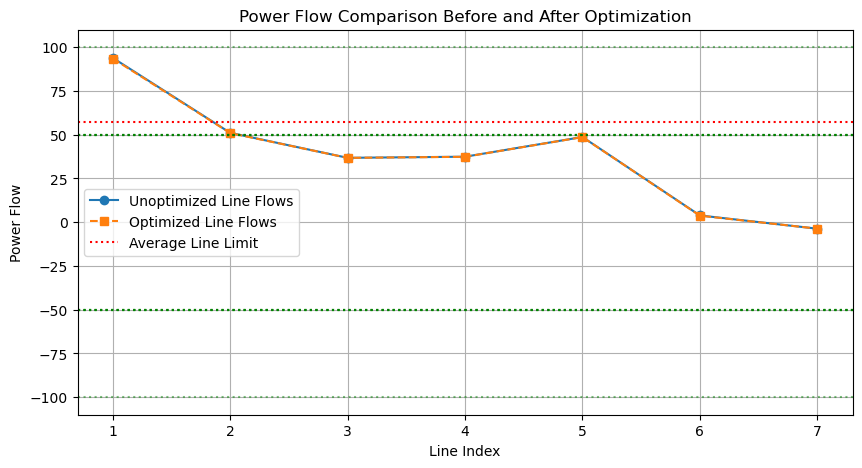

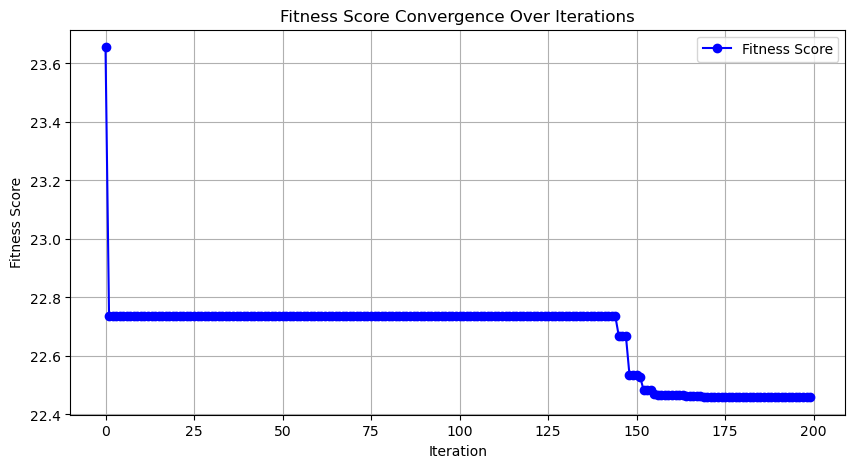

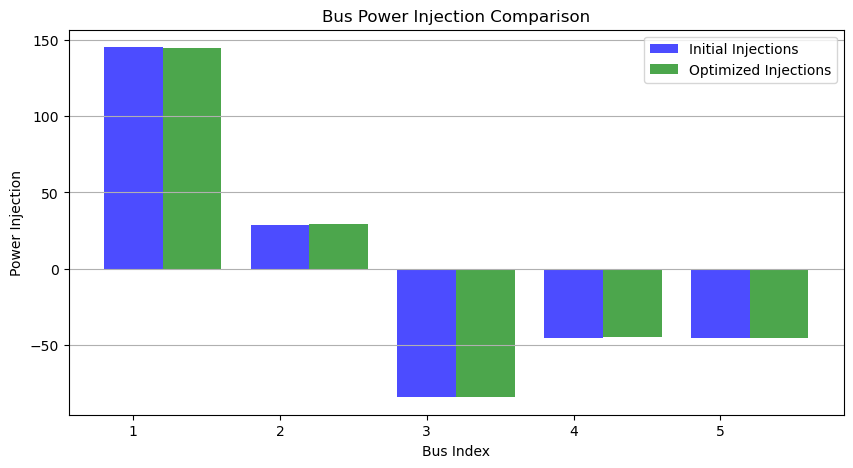

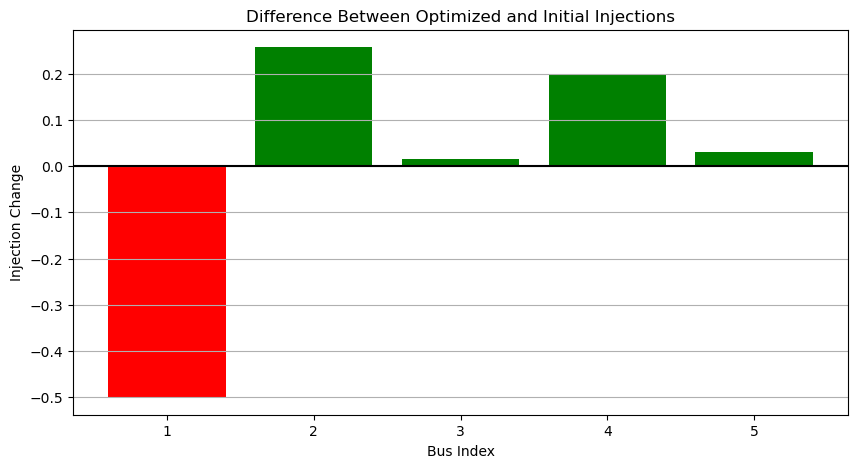


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[144.50000445]
 [ 29.25690421]
 [-83.9841521 ]
 [-44.80344632]
 [-44.96931023]]

Sum of Optimized Power Injections (Should be 0):  0.0

Resultant Line Flows After Optimization (7x1):
 [[93.53974164]
 [50.96026281]
 [36.76775869]
 [37.38548497]
 [48.64437798]
 [ 3.73391633]
 [-3.67506775]]

Changes to Power Injections:
Absolute Changes: [0.49999555 0.25690421 0.0158479  0.19655368 0.03068977]
Sum of Absolute Changes: 1.00

In [17]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        
    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        
        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)
                
                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    
                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.4f}")
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal and below sum difference threshold
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:  
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.4f} (max allowed: {self.max_sum_diff})")
                    break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.4f} (max allowed: {self.max_sum_diff})")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)
        
        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)
            
            # Ensure power balance
            new_solution -= np.mean(new_solution)
            
            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.4f}")
        
        return best_solution
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B that respects sum diff constraint"""
        max_attempts = 10
        
        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean() 
            random_solution -= np.mean(random_solution)  # Ensure power balance
            
            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution
        
        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint
        
        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        
        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)
        
        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10
        
        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all constraints including sum diff)"""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        line_constraints_met = np.all(abs(C.flatten()) <= self.line_limits)
        
        # Check sum difference constraint
        sum_diff = np.sum(np.abs(solution - solution))  # This is comparing to itself, which is wrong. Should be original_B
        # But since we don't have access to original_B here, we'll check this in the main optimize loop
        
        return line_constraints_met
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            
            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))
            
            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
    plt.xlabel('Iteration')
    plt.ylabel('Fitness Score')
    plt.title('Fitness Score Convergence Over Iterations')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.4f} (Constraint: < {max_sum_diff})")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check sum difference constraint
    if sum_diff > max_sum_diff:
        print(f"\nWARNING: Sum of differences ({sum_diff:.4f}) exceeds constraint ({max_sum_diff})")
    else:
        print(f"\nSum difference constraint satisfied: {sum_diff:.4f} < {max_sum_diff}")

    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("Enter priority for minimizing changes (0.1-0.9, higher = more emphasis on minimal changes): "))
    
    # User input for maximum sum difference constraint (default 4.0)
    max_sum_diff = float(input("Enter maximum allowed sum of differences (recommended: 4.0): "))
    
    # Run optimization
    B_optimized, fitness_history, C_optimized, C_unoptimized = optimize_power_flow(A, B, line_limits, alpha=alpha, max_sum_diff=max_sum_diff)
    
    # Visualize and report results
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=max_sum_diff)

Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50
Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45
Enter maximum allowed sum of differences (recommended: 4.0):  5.757



Algorithm Contributions:
OOA: 36.0%
KHA: 36.4%
SHO: 27.6%

Final sum of differences: 5.7569 (max allowed: 5.757)


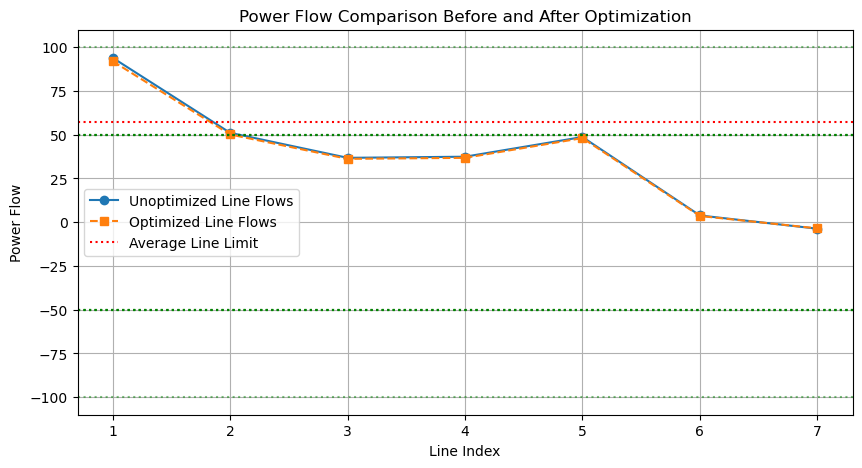

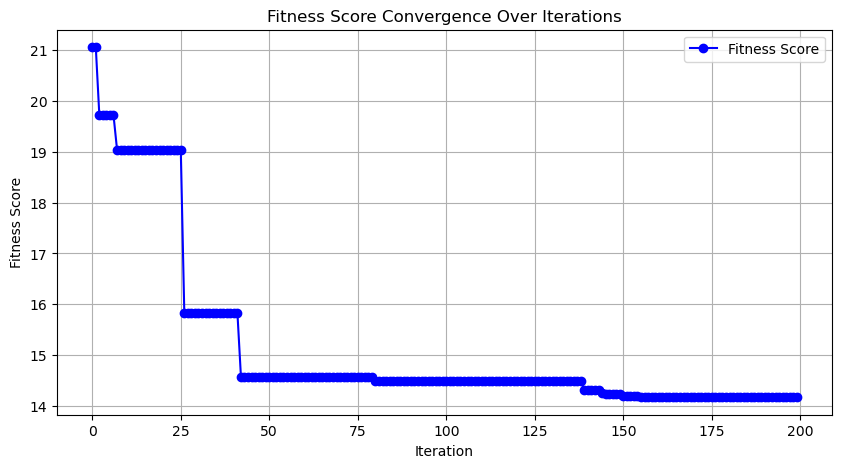

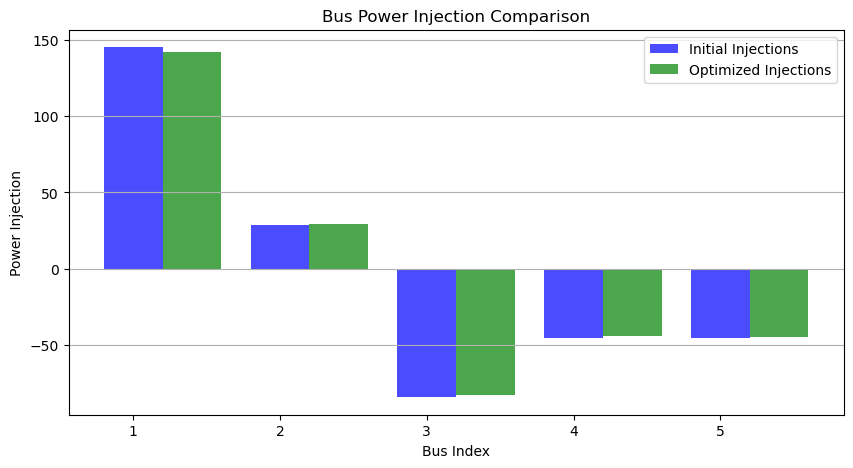

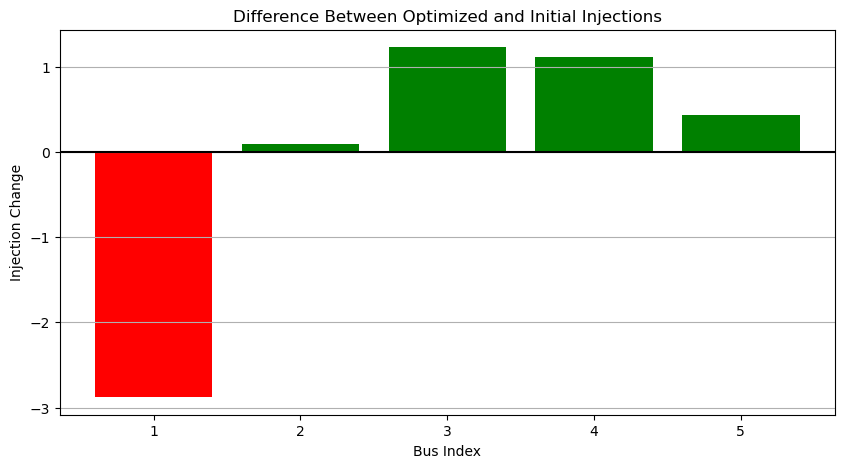


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[142.12156958]
 [ 29.09392713]
 [-82.77112588]
 [-43.88215353]
 [-44.5622173 ]]

Sum of Optimized Power Injections (Should be 0):  -7.105427357601002e-15

Resultant Line Flows After Optimization (7x1):
 [[91.97630284]
 [50.14526674]
 [36.20227667]
 [36.79218003]
 [48.07668477]
 [ 3.56666159]
 [-3.51446747]]

Changes to Power Injections:
Absolute Changes: [2.87843042 0.09392713 1.22887412 1.11784647 0.4377827 ]
Sum of Abs

In [17]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        
    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        
        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)
                
                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    
                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.4f}")
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal and below sum difference threshold
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:  
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.4f} (max allowed: {self.max_sum_diff})")
                    break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.4f} (max allowed: {self.max_sum_diff})")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)
        
        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)
            
            # Ensure power balance
            new_solution -= np.mean(new_solution)
            
            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.4f}")
        
        return best_solution
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B that respects sum diff constraint"""
        max_attempts = 10
        
        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean() 
            random_solution -= np.mean(random_solution)  # Ensure power balance
            
            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution
        
        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint
        
        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        
        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)
        
        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10
        
        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all constraints including sum diff)"""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        line_constraints_met = np.all(abs(C.flatten()) <= self.line_limits)
        
        # Check sum difference constraint
        sum_diff = np.sum(np.abs(solution - solution))  # This is comparing to itself, which is wrong. Should be original_B
        # But since we don't have access to original_B here, we'll check this in the main optimize loop
        
        return line_constraints_met
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            
            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))
            
            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
    plt.xlabel('Iteration')
    plt.ylabel('Fitness Score')
    plt.title('Fitness Score Convergence Over Iterations')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.4f} (Constraint: < {max_sum_diff})")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check sum difference constraint
    if sum_diff > max_sum_diff:
        print(f"\nWARNING: Sum of differences ({sum_diff:.4f}) exceeds constraint ({max_sum_diff})")
    else:
        print(f"\nSum difference constraint satisfied: {sum_diff:.4f} < {max_sum_diff}")

    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = 0.9
    
    # User input for maximum sum difference constraint (default 4.0)
    max_sum_diff = float(input("Enter maximum allowed sum of differences (recommended: 4.0): "))
    
    # Run optimization
    B_optimized, fitness_history, C_optimized, C_unoptimized = optimize_power_flow(A, B, line_limits, alpha=alpha, max_sum_diff=max_sum_diff)
    
    # Visualize and report results
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=max_sum_diff)

In [17]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        
    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        
        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)
                
                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    
                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}")
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal and below sum difference threshold
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:  
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)
        
        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)
            
            # Ensure power balance
            new_solution -= np.mean(new_solution)
            
            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")
        
        return best_solution
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B that respects sum diff constraint"""
        max_attempts = 10
        
        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean() 
            random_solution -= np.mean(random_solution)  # Ensure power balance
            
            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution
        
        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint
        
        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        
        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)
        
        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10
        
        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)"""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        line_constraints_met = np.all(abs(C.flatten()) <= self.line_limits)
        
        return line_constraints_met
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            
            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))
            
            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0, 
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001):
    print("Starting incremental search for minimum sum difference...")
    
    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')
    
    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(abs(C_unoptimized.flatten()) <= line_limits):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0
    
    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")
    
    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None
    
    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")
        
        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)
            
            # Check if constraints are satisfied
            is_feasible = np.all(abs(C_optimized.flatten()) <= line_limits)
            
            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))
            
            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")
                
                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff
                    
                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")
                    
                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff
                        
                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")
                            
                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)
                            
                            if np.all(abs(C_opt.flatten()) <= line_limits):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")
                                
                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")
                        
                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")
                        
                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff
                
                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff
                
                # Reduce step size for more precise search
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5)
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")
                
            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")
                
                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff
                
                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size
        
        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size
    
    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0
    
    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")
    
    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = 0.9
    
    
    
    # Run optimization
    B_optimized, fitness_history, C_optimized, C_unoptimized = optimize_power_flow(A, B, line_limits, alpha=alpha, max_sum_diff=max_sum_diff)
    
    # Visualize and report results
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=max_sum_diff)

Enter power limit for Line 1:  


ValueError: could not convert string to float: ''

Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  1



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.00696000

Attempt 1: Testing max_sum_diff = 0.00000000

Algorithm Contributions:
OOA: 37.0%
KHA: 34.4%
SHO: 28.6%

Final sum of differences: 0.000000 (max allowed: 0.00000000)
✗ INFEASIBLE solution with sum_diff = 0.00000000

Attempt 2: Testing max_sum_diff = 0.00696000

Algorithm Contributions:
OOA: 35.3%
KHA: 37.6%
SHO: 27.2%

Final sum of differences: 0.006930 (max allowed: 0.00696000)
✗ INFEASIBLE solution with sum_diff = 0.00696000

Attempt 3: Testing max_sum_diff = 0.01392000
Iteration 110: Sum of differences = 0.009208
Iteration 120: Sum of differences = 0.011861

Algorithm Contributions:
OOA: 35.2%
KHA: 35.9%
SHO: 28.8%

Final sum of differences: 0.013880 (max allowed: 0.01392000)
✗ INFEASIBLE solution with sum_diff = 0.01392000

Attempt 4: Testing max_sum_diff = 0.02088000

Algorithm Contributions:
OOA: 34.8%
KH

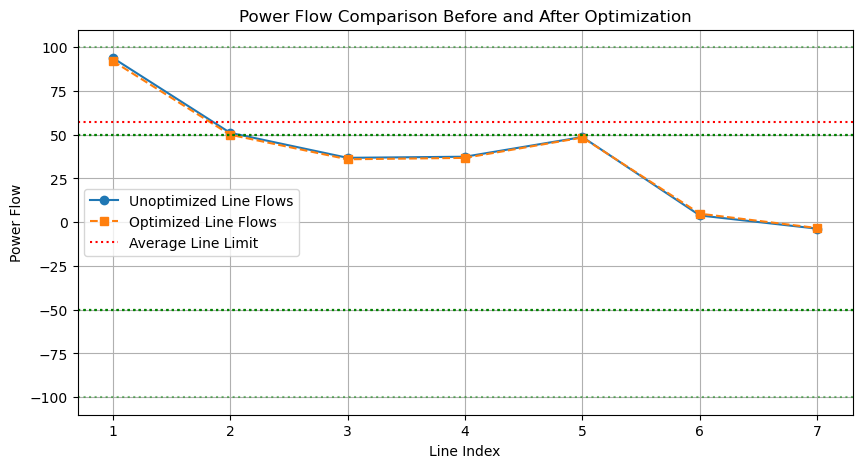

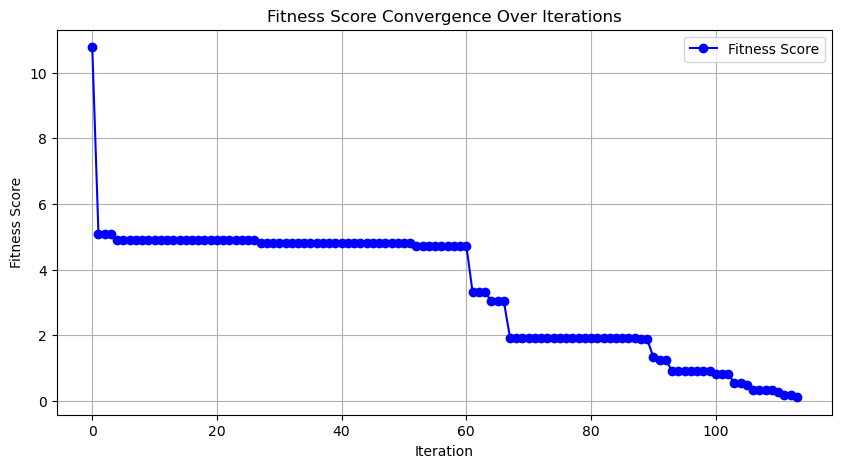

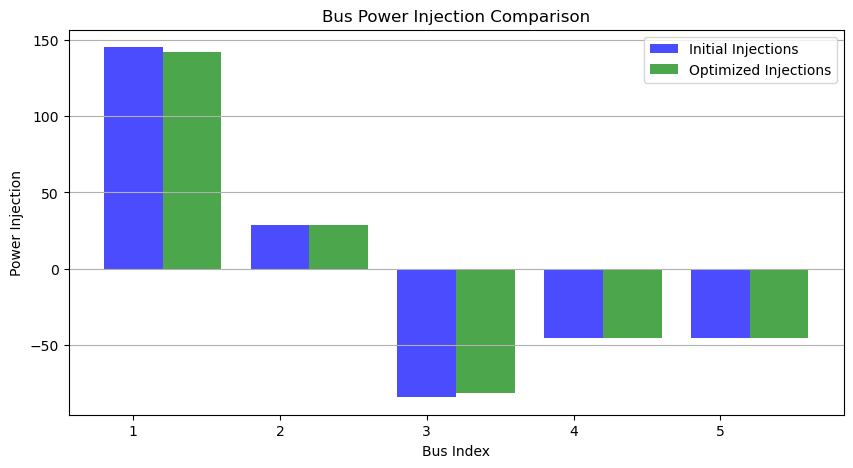

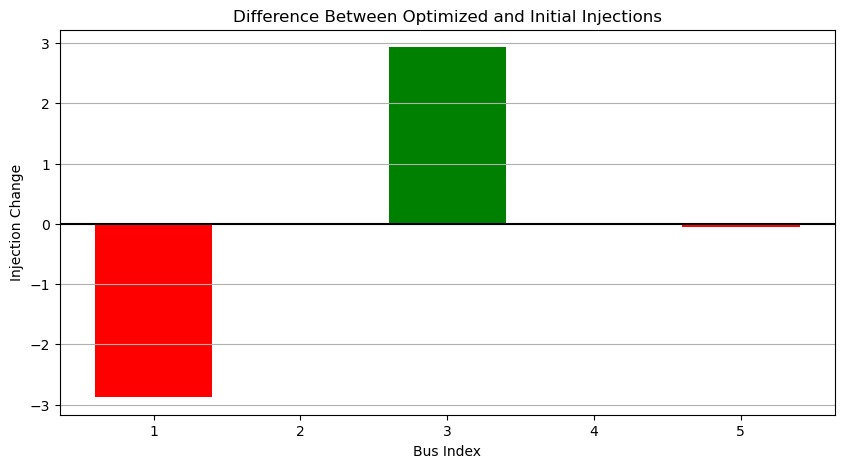


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[142.12242837]
 [ 28.99968422]
 [-81.07078207]
 [-44.99320916]
 [-45.05812135]]

Sum of Optimized Power Injections (Should be 0):  7.105427357601002e-15

Resultant Line Flows After Optimization (7x1):
 [[92.12265925]
 [49.99976912]
 [35.95954079]
 [36.76828942]
 [48.39521455]
 [ 4.87882141]
 [-3.3370932 ]]

Changes to Power Injections:
Absolute Changes: [2.87757163e+00 3.15782387e-04 2.92921793e+00 6.79083588e-03
 5.8121


Do you want to save the results to a file? (y/n):  n

Do you want to run another scenario? (y/n):  n



Thank you for using the Hybrid Power Flow Optimizer!


In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        
    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        
        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)
                
                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    
                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}")
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal and below sum difference threshold
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:  
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)
        
        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)
            
            # Ensure power balance
            new_solution -= np.mean(new_solution)
            
            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")
        
        return best_solution
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B that respects sum diff constraint"""
        max_attempts = 10
        
        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean() 
            random_solution -= np.mean(random_solution)  # Ensure power balance
            
            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution
        
        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint
        
        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        
        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)
        
        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10
        
        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)"""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        line_constraints_met = np.all(abs(C.flatten()) <= self.line_limits)
        
        return line_constraints_met
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            
            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))
            
            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0, 
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001):
    print("Starting incremental search for minimum sum difference...")
    
    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')
    
    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(abs(C_unoptimized.flatten()) <= line_limits):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0
    
    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")
    
    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None
    
    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")
        
        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)
            
            # Check if constraints are satisfied
            is_feasible = np.all(abs(C_optimized.flatten()) <= line_limits)
            
            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))
            
            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")
                
                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff
                    
                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")
                    
                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff
                        
                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")
                            
                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)
                            
                            if np.all(abs(C_opt.flatten()) <= line_limits):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")
                                
                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")
                        
                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")
                        
                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff
                
                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff
                
                # Reduce step size for more precise search
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5)
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")
                
            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")
                
                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff
                
                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size
        
        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size
    
    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0
    
    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")
    
    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))
    
    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B, line_limits, alpha=alpha)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, 
                     fitness_history, max_sum_diff=optimal_sum_diff)
    
    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")
    
    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"
        
        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")
            
            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")
            
            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i+1}: {limit}\n")
            
            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i+1}: {injection[0]}\n")
            
            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i+1}: {injection[0]}\n")
            
            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i+1}: {flow[0]}\n")
            
            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i+1}: {flow[0]}\n")
            
            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")
            
            # Check for violations
            violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")
            
            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")
            
            print(f"Results saved to {filename}")
    
    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        print("\nRestarting program...\n")
        main()  # This will cause an error since main() is not defined
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")

Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  0.8



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.696

Attempt 1: Testing max_sum_diff = 0.000

Algorithm Contributions:
OOA: 37.2%
KHA: 35.9%
SHO: 26.9%

Final sum of differences: 0.000 (max allowed: 0.000)
✗ INFEASIBLE solution with sum_diff = 0.000

Attempt 2: Testing max_sum_diff = 0.696

Algorithm Contributions:
OOA: 36.7%
KHA: 36.4%
SHO: 27.0%

Final sum of differences: 0.696 (max allowed: 0.696)
✗ INFEASIBLE solution with sum_diff = 0.696

Attempt 3: Testing max_sum_diff = 1.392

Algorithm Contributions:
OOA: 36.8%
KHA: 34.2%
SHO: 29.0%

Final sum of differences: 1.392 (max allowed: 1.392)
✗ INFEASIBLE solution with sum_diff = 1.392

Attempt 4: Testing max_sum_diff = 2.088

Algorithm Contributions:
OOA: 36.6%
KHA: 36.0%
SHO: 27.4%

Final sum of differences: 2.088 (max allowed: 2.088)
✗ INFEASIBLE solution with sum_diff = 2.088

Attempt 5: Testing max_sum_diff = 2

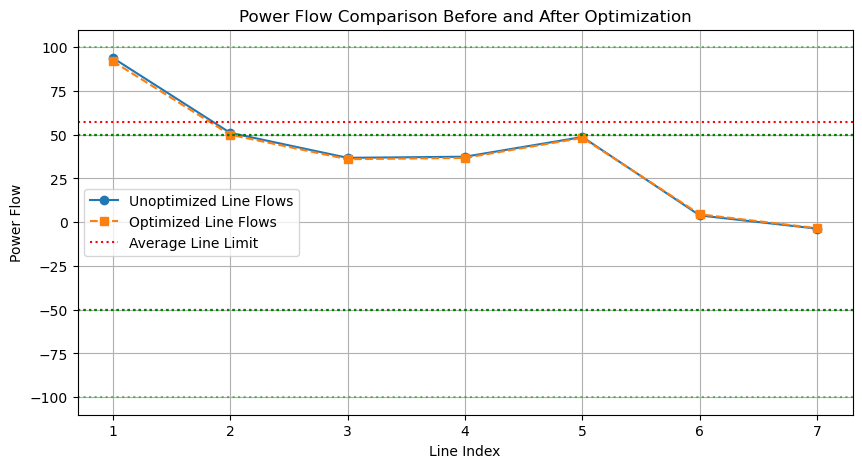

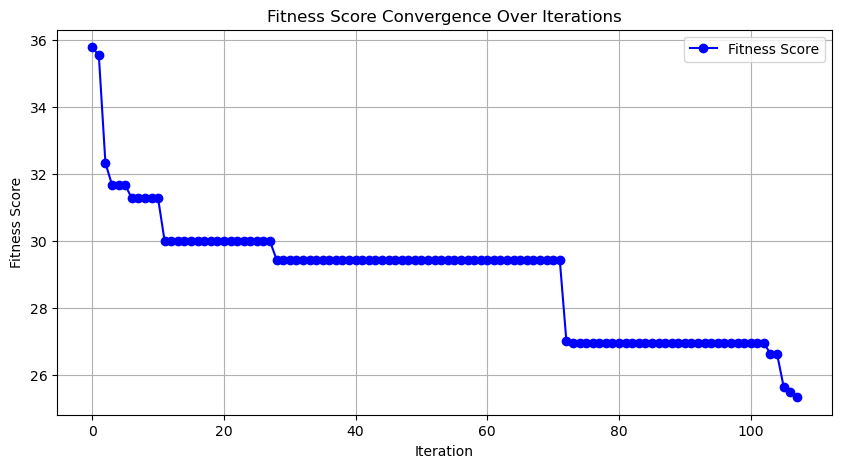

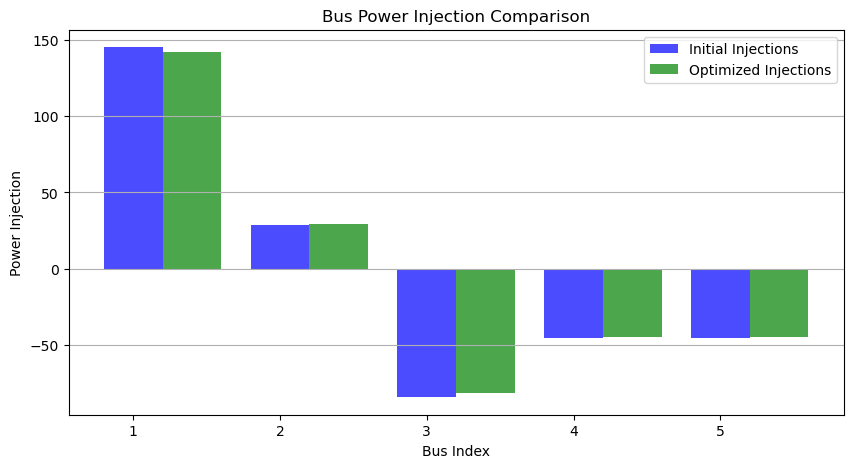

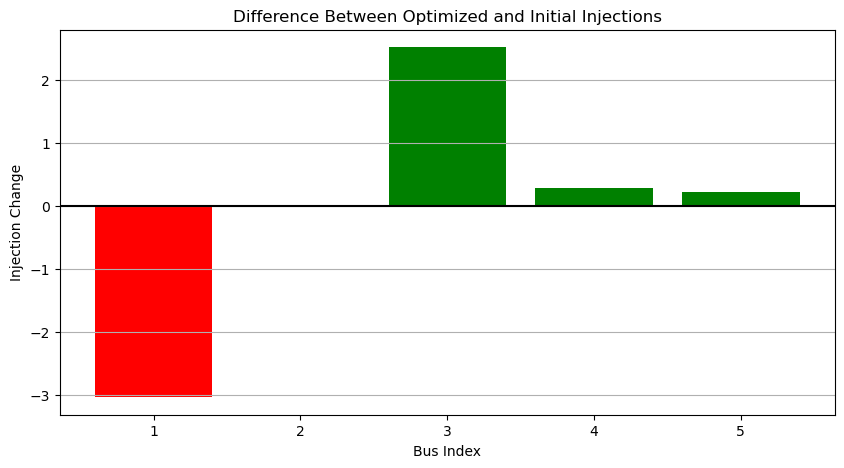


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[141.96523552]
 [ 29.01710406]
 [-81.48257844]
 [-44.71262839]
 [-44.78713275]]

Sum of Optimized Power Injections (Should be 0):  7.105427357601002e-15

Resultant Line Flows After Optimization (7x1):
 [[91.96549415]
 [49.99974137]
 [36.01187088]
 [36.76066485]
 [48.21083031]
 [ 4.51931601]
 [-3.42369756]]

Changes to Power Injections:
Absolute Changes: [3.03476448 0.01710406 2.51742156 0.28737161 0.21286725]
Sum of Abso

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences

    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory

        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}

        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}")

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal and below sum difference threshold
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.3f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.3f} (max allowed: {self.max_sum_diff:.3f})")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B that respects sum diff constraint"""
        max_attempts = 10

        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint

        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)"""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Use a small tolerance to account for floating-point inaccuracies
        tolerance = 1e-6
        line_constraints_met = np.all(abs(C.flatten()) <= self.line_limits + tolerance)
        
        return line_constraints_met


    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0

        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                            a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0    # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0

        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                        min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)

    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)

    return B_optimized, fitness_history, C_optimized, C_unoptimized

# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0, step_size=0.00000001, max_attempts=10000, min_step_size=0.00000001):
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(abs(C_unoptimized.flatten()) <= line_limits):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.01)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.3f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.3f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(abs(C_optimized.flatten()) <= line_limits + 1e-6) # Added tolerance

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.3f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.3f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(f"Switching to binary search between {last_failing_sum_diff:.3f} and {first_success_sum_diff:.3f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.3f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)

                            if np.all(abs(C_opt.flatten()) <= line_limits + 1e-6): # Added tolerance
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.3f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.3f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.3f}")

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.3f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

                # Reduce step size for more precise search
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5)
                print(f"Reducing step size to {current_step_size:.3f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.3f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0

    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.3f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i+0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")
    
    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits + 1e-6)[0] #Added tolerance
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))
    
    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B, line_limits, alpha=alpha)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, max_sum_diff=optimal_sum_diff)
    
    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")
    
    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"
        
        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")
            
            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")
            
            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i+1}: {limit}\n")
            
            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i+1}: {injection[0]}\n")
            
            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i+1}: {injection[0]}\n")
            
            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i+1}: {flow[0]}\n")
            
            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i+1}: {flow[0]}\n")
            
            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")
            
            # Check for violations
            violations = np.where(abs(C_optimized.flatten()) > line_limits + 1e-6)[0]  # Added tolerance
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")
            
            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")
            
            print(f"Results saved to {filename}")
    
    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        print("\nRestarting program...\n")

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100):
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        
    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using hybrid of OOA, KHA and SHO algorithms with memory
        
        Parameters:
        - B: Original power injections
        - iterations: Maximum number of iterations
        - population_size: Size of the population
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis)
        """
        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size//2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]
        
        # Ensure the original B is in the population
        initial_population[0] = B.copy()
        
        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)
        
        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        
        # Main optimization loop
        for iteration in range(iterations):
            # Determine which algorithm to use based on current iteration
            # Early: focus on exploration (KHA), Middle: balance (SHO), Late: exploitation (OOA)
            if iteration < iterations * 0.3:
                weights = [0.2, 0.6, 0.2]  # KHA dominant
            elif iteration < iterations * 0.7:
                weights = [0.3, 0.3, 0.4]  # SHO dominant
            else:
                weights = [0.6, 0.2, 0.2]  # OOA dominant
            
            new_population = []
            
            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Randomly select algorithm based on weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1
                
                # Ensure power balance
                new_solution -= np.mean(new_solution)
                
                # Add to new population
                new_population.append(new_solution)
                
                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)
                if fitness < best_fitness:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
            
            # Replace old population with new population
            initial_population = new_population
            
            # Record fitness history
            fitness_history.append(best_fitness)
            
            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                if deviation < 0.1:  # Stop if changes are less than 10%
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    break
        
        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)
        
        # Minimize changes to original injections while keeping line constraints satisfied
        best_solution = self._minimize_changes(best_solution, B)
        
        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)
        
        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count/total*100:.1f}%")
        
        return best_solution, fitness_history, np.dot(self.A, best_solution)
    
    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)
        
        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)
            
            # Ensure power balance
            new_solution -= np.mean(new_solution)
            
            # Check if still feasible
            if self._is_feasible(new_solution):
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%")
        
        return best_solution
    
    def _generate_random_solution(self, B):
        """Generate a random solution based on the original B"""
        # Use smaller perturbation to stay closer to original injections
        random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean() 
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution
    
    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations and deviation from original B
        
        Parameters:
        - solution: Current solution to evaluate
        - original_B: Original power injections
        - alpha: Weight for minimizing changes (higher = more emphasis)
        """
        C = np.dot(self.A, solution)
        
        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, abs(C.flatten()) - self.line_limits))
        
        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)
        
        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5
    
    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all constraints)"""
        C = np.dot(self.A, solution)
        return np.all(abs(C.flatten()) <= self.line_limits)
    
    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution"""
        if not self.memory:
            return None
        
        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')
        
        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)
            if similarity < best_similarity:
                best_similarity = similarity
                best_match = optimal_B
        
        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None
    
    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")
    
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()
        
        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]
        
        # Binary success indicator
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0
        
        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)
            
            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)
        
        return new_solution
    
    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy"""
        solution = population[index].copy()
        
        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5   # Inertia weight
        c_best = 2    # Best krill effect
        c_rand = 1    # Random krill effect
        
        # Motion induction (other krill effect)
        N_old = 0     # Previous motion
        neighbors = random.sample(population, min(3, len(population)-1))
        
        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)
        
        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)
        
        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()
        
        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)
        
        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D
        
        return new_solution
    
    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy"""
        solution = population[index].copy()
        
        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0
        
        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index], 
                                       min(3, len(population)-1))
        random_solutions = [population[i] for i in random_indices]
        
        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)
        
        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha
            
            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2
        
        return new_solution

# Function to redistribute overload to underloaded lines
def redistribute_overload(A, B, line_limits, max_iterations=50):
    """
    Redistribute power flow from overloaded lines to underloaded lines
    by adjusting bus injections
    
    Parameters:
    - A: Power flow coefficients matrix
    - B: Original power injections
    - line_limits: Maximum allowed flow for each line
    - max_iterations: Maximum iterations for redistribution
    
    Returns:
    - Adjusted power injections
    """
    print("\n--- Starting Overload Redistribution ---")
    
    # Get the current line flows
    C = np.dot(A, B)
    
    # Make a copy of the original injections
    B_adjusted = B.copy()
    
    # Perform redistribution iterations
    for iteration in range(max_iterations):
        # Get the current line flows
        C = np.dot(A, B_adjusted)
        
        # Find overloaded and underloaded lines
        overloaded_lines = np.where(abs(C.flatten()) > line_limits)[0]
        
        # If no overloaded lines, we're done
        if len(overloaded_lines) == 0:
            print(f"All line constraints satisfied after {iteration} iterations!")
            break
        
        # Find underloaded lines with capacity to absorb more flow
        underloaded_lines = np.where(abs(C.flatten()) < line_limits * 0.9)[0]
        
        if len(underloaded_lines) == 0:
            print("Warning: No underloaded lines available for redistribution!")
            break
        
        # Print current status
        print(f"\nIteration {iteration+1}:")
        print(f"Overloaded lines: {[i+1 for i in overloaded_lines]}")
        print(f"Underloaded lines: {[i+1 for i in underloaded_lines]}")
        
        # For each overloaded line, redistribute excess flow
        for line_idx in overloaded_lines:
            line_flow = C[line_idx][0]
            line_limit = line_limits[line_idx]
            excess_flow = abs(line_flow) - line_limit
            
            # Skip if excess is minimal
            if excess_flow < 0.001:
                continue
                
            print(f"Line {line_idx+1}: Flow={line_flow:.4f}, Limit={line_limit:.4f}, Excess={excess_flow:.4f}")
            
            # Choose random underloaded line to absorb flow
            target_idx = np.random.choice(underloaded_lines)
            
            # Determine the direction of the flow (positive or negative)
            flow_direction = 1 if line_flow > 0 else -1
            
            # Get the sensitivity factors for the overloaded line (to know which buses affect it most)
            sensitivity_overload = A[line_idx, :]
            
            # Get the sensitivity factors for the underloaded line
            sensitivity_underload = A[target_idx, :]
            
            # Find bus indexes with opposite sensitivities (to cancel out effect on overloaded line)
            # and enhance flow on underloaded line
            best_buses = []
            for i in range(len(sensitivity_overload)):
                if sensitivity_overload[i] * flow_direction > 0 and sensitivity_underload[i] != 0:
                    best_buses.append((i, abs(sensitivity_overload[i])))
            
            # If no good buses found, try any bus
            if not best_buses:
                best_buses = [(i, abs(sensitivity_overload[i])) for i in range(len(sensitivity_overload)) 
                              if sensitivity_overload[i] != 0]
            
            # Sort by sensitivity (highest first)
            best_buses.sort(key=lambda x: x[1], reverse=True)
            
            if not best_buses:
                print("Warning: No suitable buses found for redistribution")
                continue
                
            # Select the bus with highest sensitivity
            bus_idx, sensitivity = best_buses[0]
            
            # Calculate adjustment needed
            adjustment = -excess_flow * flow_direction / (2 * sensitivity)
            
            # Limit the adjustment size to avoid overcompensation
            adjustment = max(min(adjustment, 0.1), -0.1)
            
            # Adjust the bus injection
            B_adjusted[bus_idx][0] += adjustment
            
            # Find a compensating bus to maintain power balance
            other_buses = [i for i in range(len(B_adjusted)) if i != bus_idx]
            comp_bus_idx = np.random.choice(other_buses)
            B_adjusted[comp_bus_idx][0] -= adjustment
            
            print(f"Adjusted Bus {bus_idx+1} by {adjustment:.4f} and Bus {comp_bus_idx+1} by {-adjustment:.4f}")
            
            # Update flows after adjustment
            C = np.dot(A, B_adjusted)
            
            # Update overloaded and underloaded lists after this adjustment
            overloaded_lines = np.where(abs(C.flatten()) > line_limits)[0]
            underloaded_lines = np.where(abs(C.flatten()) < line_limits * 0.9)[0]
            
            if len(overloaded_lines) == 0:
                print("All constraints satisfied after this adjustment!")
                break
    
    # Make final adjustment to ensure power balance
    B_adjusted -= np.mean(B_adjusted)
    
    # Print final status
    C_final = np.dot(A, B_adjusted)
    final_violations = np.where(abs(C_final.flatten()) > line_limits)[0]
    
    if len(final_violations) > 0:
        print(f"\nWarning: {len(final_violations)} line constraints still violated after redistribution!")
        for line in final_violations:
            print(f"  Line {line+1}: Flow = {abs(C_final[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied after redistribution!")
    
    return B_adjusted, C_final

# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, use_redistribution=True):
    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)
    
    # Check for overloaded lines
    overloaded = np.where(abs(C_unoptimized.flatten()) > line_limits)[0]
    
    # If there are overloaded lines and redistribution is enabled
    if len(overloaded) > 0 and use_redistribution:
        print(f"\nFound {len(overloaded)} overloaded lines in the initial solution!")
        print("Lines:", [i+1 for i in overloaded])
        
        # Try to redistribute flows first
        B_redistributed, C_redistributed = redistribute_overload(A, B, line_limits)
        
        # Check if redistribution was successful
        still_overloaded = np.where(abs(C_redistributed.flatten()) > line_limits)[0]
        
        if len(still_overloaded) == 0:
            print("\nSuccessfully redistributed flows without using the optimizer!")
            return B_redistributed, [], C_redistributed, C_unoptimized
        else:
            print("\nRedistribution helped but couldn't fully solve the problem.")
            print(f"Still have {len(still_overloaded)} overloaded lines.")
            print("Will now run the full optimizer using the redistributed solution as starting point.")
            
            # Use the redistributed solution as the starting point for optimization
            B_start = B_redistributed
    else:
        # No overloaded lines or redistribution disabled
        B_start = B.copy()
    
    # Run the Hybrid Optimization with Memory
    optimizer = HybridPowerFlowOptimizer(A, line_limits)
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B_start, iterations, alpha=alpha)
    
    return B_optimized, fitness_history, C_optimized, C_unoptimized

# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history):
    # Plot line flow comparison
    plt.figure(figsize=(12, 6))
    
    # Create bar indices
    line_indices = np.arange(len(C_unoptimized))
    
    # Plot as bars for better comparison
    bar_width = 0.35
    plt.bar(line_indices - bar_width/2, C_unoptimized.flatten(), 
            width=bar_width, label='Unoptimized Line Flows', color='red', alpha=0.7)
    plt.bar(line_indices + bar_width/2, C_optimized.flatten(), 
            width=bar_width, label='Optimized Line Flows', color='green', alpha=0.7)

    # Plot line limits
    for i in range(len(line_limits)):
        plt.axhline(y=line_limits[i], color='blue', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='blue', linestyle=':', alpha=0.5)

    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.xticks(line_indices, [f"Line {i+1}" for i in range(len(C_unoptimized))])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Only plot fitness history if we ran the optimizer
    if len(fitness_history) > 0:
        # Plot fitness score history
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b', label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(12, 6))
    bus_indices = np.arange(len(B))
    
    plt.bar(bus_indices - bar_width/2, B.flatten(), 
            width=bar_width, label='Initial Injections', color='blue', alpha=0.7)
    plt.bar(bus_indices + bar_width/2, B_optimized.flatten(), 
            width=bar_width, label='Optimized Injections', color='green', alpha=0.7)
    
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.xticks(bus_indices, [f"Bus {i+1}" for i in range(len(B))])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(12, 6))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(bus_indices, changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.xticks(bus_indices, [f"Bus {i+1}" for i in range(len(B))])
    plt.grid(True, alpha=0.3)
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Print results
    print("\nMatrix A (Power Flow Coefficients):\n", A)
    print("\nInitial Power Injections (B):\n", B.flatten())
    print("\nResultant Line Flows Before Optimization:\n", C_unoptimized.flatten())
    print("\nOptimized Power Injections (B_optimized):\n", B_optimized.flatten())
    print("\nSum of Optimized Power Injections (Should be near 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization:\n", C_optimized.flatten())
    
    # Print line limits comparison
    print("\nLine Limits vs Actual Flows:")
    for i in range(len(line_limits)):
        initial_flow = abs(C_unoptimized[i][0])
        final_flow = abs(C_optimized[i][0])
        limit = line_limits[i]
        status_before = "OVERLOADED" if initial_flow > limit else "OK"
        status_after = "OVERLOADED" if final_flow > limit else "OK"
        utilization_before = initial_flow / limit * 100
        utilization_after = final_flow / limit * 100
        
        print(f"Line {i+1}: Limit={limit:.4f}, Before={initial_flow:.4f} ({utilization_before:.1f}% - {status_before}), " 
              f"After={final_flow:.4f} ({utilization_after:.1f}% - {status_after})")
    
    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B)/np.linalg.norm(B)*100:.2f}%")

    # Check that constraints are satisfied
    violations = np.where(abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line+1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {((np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)))/np.sum(abs(C_unoptimized)))*100:.6f}%")

# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])

    # User options for input method
    print("Power Flow Optimization with Overload Redistribution\n")
    input_method = input("Choose input method: (1) Manual input (2) Example values: ")
    
    if input_method == "2":
        # Example values
        line_limits = np.array([1.5, 0.8, 1.2, 1.0, 1.3, 0.9, 0.7])
        B = np.array([2.0, -1.5, 0.8, -0.6, -0.7]).reshape(5, 1)
        alpha = 0.7
    else:
        # User input for Line Power Limits (7 lines)
        line_limits = np.array([float(input(f"Enter power limit for Line {i+1}: ")) for i in range(7)])

        # User input for Bus Injection Matrix B (5x1)
        B = np.array([float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(5)]).reshape(5, 1)

        # User input for weighting factor (how much to prioritize minimal changes)
        alpha = float(input("Enter priority for minimizing changes (0.1-0.9, higher = more emphasis on minimal changes): "))
    
    # Enable/disable redistribution
    use_redistribution = True
    redistribution_option = input("\nUse flow redistribution first? (y/n): ").lower()
    if redistribution_option.startswith('n'):
        use_redistribution = False
    
       # Run optimization
    B_optimized, fitness_history, C_optimized, C_unoptimized = optimize_power_flow(
        A, B, line_limits, iterations=200, alpha=alpha, use_redistribution=use_redistribution
    )
    
    # Display results
    print("\n=== Optimization Complete ===")
    print("\nFinal Optimized Power Injections (B_optimized):")
    print(B_optimized)
    
    print("\nFinal Line Flows After Optimization:")
    print(C_optimized)
    
    # Visualize results
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history)
    
    # Summary of improvement
    initial_violation_count = np.sum(abs(C_unoptimized.flatten()) > line_limits)
    final_violation_count = np.sum(abs(C_optimized.flatten()) > line_limits)
    
    if final_violation_count == 0:
        print("\n✅ All line constraints satisfied after optimization!")
    else:
        print(f"\n⚠️ {final_violation_count} line constraints still violated after optimization.")

    initial_total_flow = np.sum(abs(C_unoptimized))
    final_total_flow = np.sum(abs(C_optimized))
    
    print(f"\nInitial Total Line Flow: {initial_total_flow:.4f}")
    print(f"Final Total Line Flow: {final_total_flow:.4f}")
    print(f"Difference: {final_total_flow - initial_total_flow:.4f}")
    print(f"Percentage Improvement: {((initial_total_flow - final_total_flow) / initial_total_flow) * 100:.2f}%")
    
    # Save the optimized solution (Optional)
    save_option = input("\nSave optimized solution to file? (y/n): ").lower()
    if save_option.startswith('y'):
        np.savetxt("optimized_solution.txt", B_optimized, fmt="%.6f")
        print("✅ Optimized solution saved to 'optimized_solution.txt'")

    print("\n=== Program Complete ===")


Power Flow Optimization with Overload Redistribution



KeyboardInterrupt: Interrupted by user

Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  1



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.00696000

Attempt 1: Testing max_sum_diff = 0.00000000
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected. 

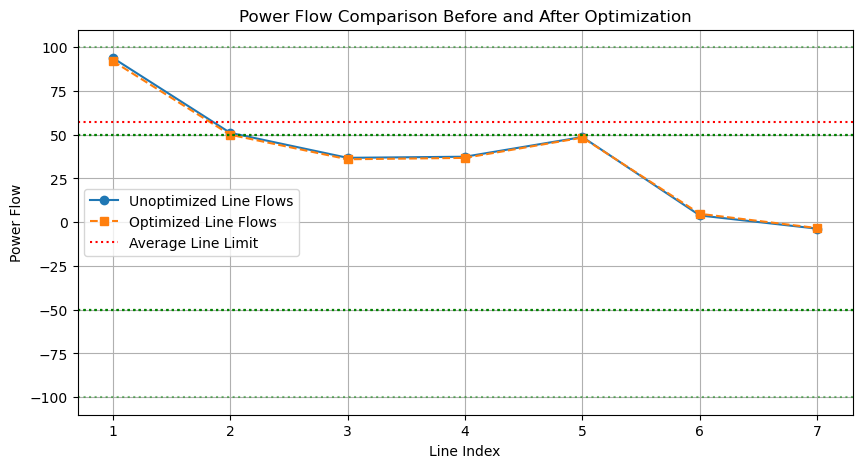

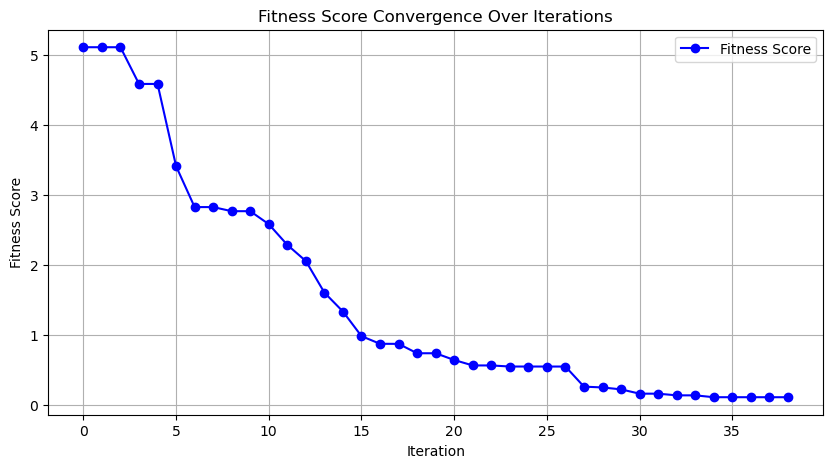

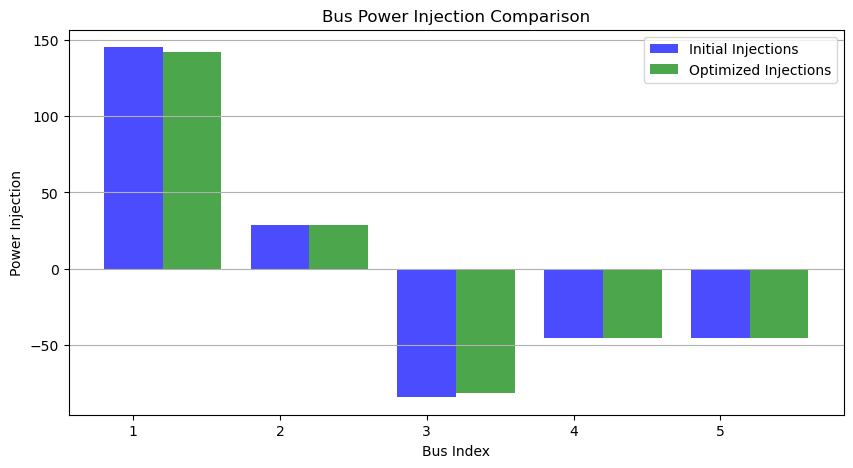

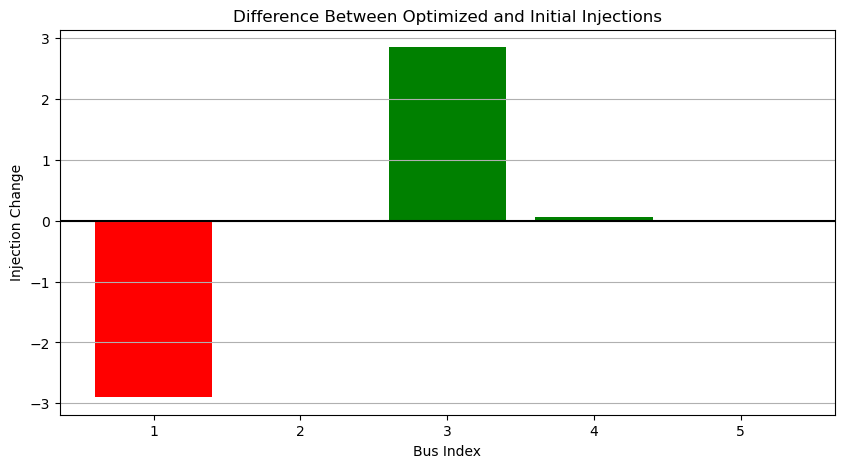


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[142.09981838]
 [ 28.98321874]
 [-81.1511658 ]
 [-44.9342883 ]
 [-44.99758302]]

Sum of Optimized Power Injections (Should be 0):  -1.4210854715202004e-14

Resultant Line Flows After Optimization (7x1):
 [[92.09993309]
 [49.99988528]
 [35.96726522]
 [36.76391565]
 [48.35268801]
 [ 4.80627448]
 [-3.35510498]]

Changes to Power Injections:
Absolute Changes: [2.90018162e+00 1.67812561e-02 2.84883420e+00 6.57117044e-02
 2.41


Do you want to save the results to a file? (y/n):  y
Enter filename (default: power_flow_results.txt):  tr


Results saved to tr



Do you want to run another scenario? (y/n):  n



Thank you for using the Hybrid Power Flow Optimizer!


In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import time  # Import the time module for performance tracking


# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        """
        Initialize the optimizer.

        Parameters:
        - A_matrix: The power flow matrix.
        - line_limits: The line capacity limits.
        - memory_size: The size of the solution memory.
        - max_sum_diff: The maximum allowed sum of differences between original and optimized injections.
        """
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.algorithm_weights = {'OOA': 0.3, 'KHA': 0.3, 'SHO': 0.4}  # Initial algorithm weights
        self.adaptive_weights = True # Control adaptive weights.

    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using a hybrid of OOA, KHA, and SHO algorithms with memory.

        Parameters:
        - B: Original power injections.
        - iterations: Maximum number of iterations.
        - population_size: Size of the population.
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis).
        """
        start_time = time.time()  # Record the start time

        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size // 2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size // 2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        algorithm_successes = {'OOA': 0, 'KHA': 0, 'SHO': 0}  # Track algorithm success
        stagnation_counter = 0
        previous_best_fitness = best_fitness

        # Main optimization loop
        for iteration in range(iterations):
            if self.adaptive_weights:
                self._update_algorithm_weights(algorithm_successes) # Update weights adaptively

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Select algorithm based on adaptive weights
                algorithm = random.choices(list(self.algorithm_weights.keys()),
                                           weights=list(self.algorithm_weights.values()), k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration,
                                                                 iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    algorithm_successes[algorithm] += 1 # Increment algorithm success counter

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}, Best Fitness: {best_fitness:.6f}")
                else:
                    algorithm_successes[algorithm] *= 0.9  # Decay success if not improved

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Check for stagnation and adapt algorithms if necessary
            if abs(best_fitness - previous_best_fitness) < 1e-6:
                stagnation_counter += 1
                if stagnation_counter >= 10:  # Increased stagnation threshold
                    print("Stagnation detected.  Re-initializing some solutions.")
                    # Re-initialize a portion of the population to increase diversity
                    for i in range(population_size // 4):  # Re-initialize 25% of population
                        initial_population[random.randint(0, population_size - 1)] = self._generate_random_solution(B)
                    stagnation_counter = 0  # Reset counter
            else:
                stagnation_counter = 0
            previous_best_fitness = best_fitness

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count / total * 100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")

        end_time = time.time()  # Record the end time
        print(f"Optimization time: {end_time - start_time:.2f} seconds")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _update_algorithm_weights(self, algorithm_successes):
        """
        Dynamically update algorithm weights based on their recent success.
        """
        total_success = sum(algorithm_successes.values())
        if total_success > 0:
            for algo in self.algorithm_weights:
                # Update weight based on success rate, with a smoothing factor
                self.algorithm_weights[algo] = 0.8 * self.algorithm_weights[algo] + 0.2 * (
                        algorithm_successes[algo] / total_success)
        else:
            #If no success, keep weights as they are
            pass

        # Normalize weights to sum to 1
        total_weight = sum(self.algorithm_weights.values())
        for algo in self.algorithm_weights:
            self.algorithm_weights[algo] /= total_weight

    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint.

        Parameters:
        - solution: The current solution.
        - original_B: The original power injections.
        - steps: Number of steps to take in the minimization process.
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """
        Generate a random solution based on the original B that respects the sum diff constraint.

        Parameters:
        - B: The original power injections.
        """
        max_attempts = 10

        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint.

        Parameters:
        - solution: Current solution to evaluate.
        - original_B: Original power injections.
        - alpha: Weight for minimizing changes (higher = more emphasis).
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, np.abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)."""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        line_constraints_met = np.all(np.abs(C.flatten()) <= self.line_limits)

        return line_constraints_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution."""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory."""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy."""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator (simplified)
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution, solution) else 0


        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy."""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5  # Inertia weight
        c_best = 2  # Best krill effect
        c_rand = 1  # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0  # Previous motion
        neighbors = random.sample(population, min(3, len(population) - 1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy."""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0

        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                       min(3, len(population) - 1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution


# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    """
    Optimize power flow using the HybridPowerFlowOptimizer.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - iterations: The maximum number of iterations.
    - alpha: The weighting factor for minimizing changes.
    - max_sum_diff: Maximum allowed sum of differences.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    """
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)

    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)

    return B_optimized, fitness_history, C_optimized, C_unoptimized


# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001):
    """
    Incrementally find the minimum sufficient sum_diff that leads to a feasible solution.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - alpha: Weighting factor.
    - start_sum_diff: Starting sum difference.
    - step_size: Initial step size.
    - max_attempts: Maximum number of attempts.
    - min_step_size: Minimum step size allowed.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    - best_feasible_sum_diff: The minimum sum difference found.
    """
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(np.abs(C_unoptimized.flatten()) <= line_limits):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(np.abs(C_optimized.flatten()) <= line_limits)

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(
                            f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)

                            if np.all(np.abs(C_opt.flatten()) <= line_limits):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[
                        2], C_unoptimized, best_feasible_sum_diff

                # Reduce step size for more precise search
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5)
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0

    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[
        2], C_unoptimized, best_feasible_sum_diff


# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    """
    Visualize the results of the power flow optimization.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - B_optimized: The optimized power injections.
    - C_optimized: The optimized line flows.
    - C_unoptimized: The unoptimized line flows.
    - line_limits: The line capacity limits.
    - fitness_history: The history of fitness values.
    - max_sum_diff: Maximum allowed sum of differences
    """
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b',
                 label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i + 0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7,
            color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B) / np.linalg.norm(B) * 100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")

    # Check that constraints are satisfied
    violations = np.where(np.abs(C_optimized.flatten()) > line_limits)[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line + 1}: Flow = {np.abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(np.abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(np.abs(C_optimized)))
    print(f"Difference: {np.sum(np.abs(C_optimized)) - np.sum(np.abs(C_unoptimized)):.6f}")
    print(
        f"Percentage Difference: {((np.sum(np.abs(C_optimized)) - np.sum(np.abs(C_unoptimized))) / np.sum(
            np.abs(C_unoptimized))) * 100:.6f}%")



# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
        [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
        [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
        [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B, line_limits,
                                                                                                      alpha=alpha)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, max_sum_diff=optimal_sum_diff)

    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")

            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")

            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i + 1}: {limit}\n")

            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

            # Check for violations
            violations = np.where(np.abs(C_optimized.flatten()) > line_limits)[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(
                        f"  Line {line + 1}: Flow = {np.abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")

            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")

            print(f"Results saved to {filename}")

    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        print("\nRestarting program...\n")
        # Instead of calling main(), which can lead to recursion issues, just re-execute the main part of the code
        if __name__ == "__main__":
            # Define the given 7x5 matrix (Power Flow Coefficients)
            A = np.array([
                [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
                [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
                [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
                [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
                [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
                [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
                [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
            ])

            # User input for Line Power Limits (7 lines)
            print("Enter power limits for each line:")
            line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

            # User input for Bus Injection Matrix B (5x1)
            print("\nEnter power injections for each bus:")
            B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

            # User input for weighting factor (how much to prioritize minimal changes)
            alpha = float(input(
                "\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

            # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
            print("\nStarting incremental optimization to find minimum required sum of differences...")
            B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(
                A, B, line_limits, alpha=alpha)
            print("\nVisualization of optimization results with minimum required sum of differences...")
            visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                              fitness_history, max_sum_diff=optimal_sum_diff)

            print("\nOptimization complete!")
            print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")


Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  1



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.00696000

Attempt 1: Testing max_sum_diff = 0.00000000
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected. 

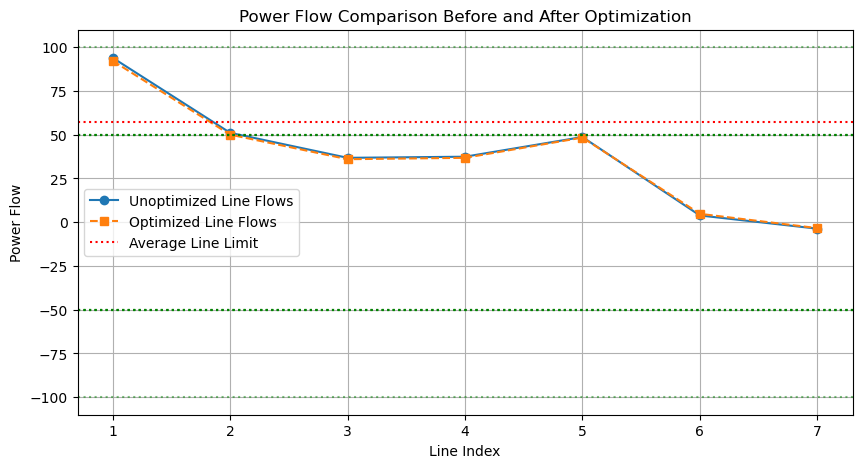

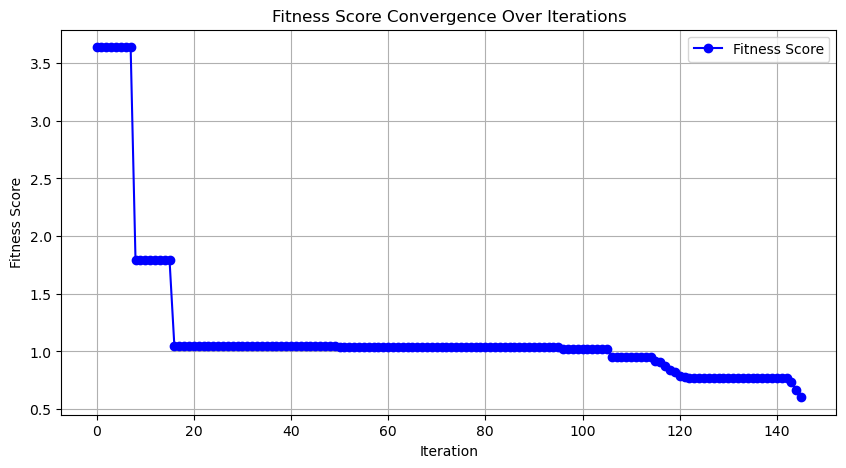

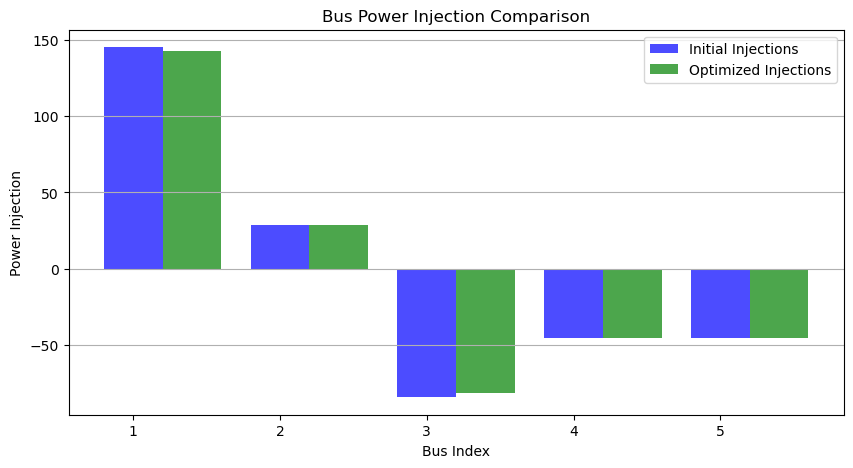

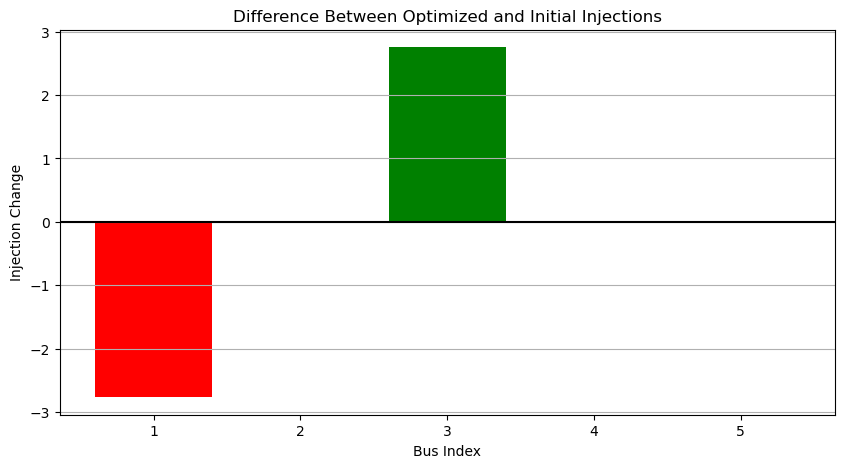


Matrix A (7x5):
 [[ 0.5857 -0.2571 -0.0428 -0.0857 -0.2   ]
 [ 0.2143  0.0571 -0.1572 -0.1143 -0.    ]
 [ 0.0905  0.1619 -0.1953 -0.1238  0.0666]
 [ 0.108   0.1651 -0.1206 -0.1968  0.0444]
 [ 0.1872  0.2158  0.073   0.0349 -0.5109]
 [ 0.1048  0.0191  0.4476 -0.438  -0.1334]
 [ 0.0128 -0.0158  0.127   0.1651 -0.2891]]

Initial Power Injections (B, 5x1):
 [[145.]
 [ 29.]
 [-84.]
 [-45.]
 [-45.]]

Resultant Line Flows Before Optimization (7x1):
 [[93.9223]
 [51.0777]
 [36.7968]
 [37.4363]
 [48.6902]
 [ 3.8645]
 [-3.6902]]

Optimized Power Injections (B_optimized, 5x1):
 [[142.23363784]
 [ 28.99101696]
 [-81.24674203]
 [-44.98579854]
 [-44.99211424]]

Sum of Optimized Power Injections (Should be 0):  2.1316282072803006e-14

Resultant Line Flows After Optimization (7x1):
 [[92.18371756]
 [50.04992028]
 [36.00604564]
 [36.80156216]
 [48.36785309]
 [ 4.79949974]
 [-3.37573885]]

Changes to Power Injections:
Absolute Changes: [2.76636216 0.00898304 2.75325797 0.01420146 0.00788576]
Sum of Abs


Do you want to save the results to a file? (y/n):  y
Enter filename (default: power_flow_results.txt):  


Results saved to power_flow_results.txt



Do you want to run another scenario? (y/n):  n



Thank you for using the Hybrid Power Flow Optimizer!


In [13]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import time  # Import the time module for performance tracking


# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        """
        Initialize the optimizer.

        Parameters:
        - A_matrix: The power flow matrix.
        - line_limits: The line capacity limits.
        - memory_size: The size of the solution memory.
        - max_sum_diff: The maximum allowed sum of differences between original and optimized injections.
        """
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.algorithm_weights = {'OOA': 0.3, 'KHA': 0.3, 'SHO': 0.4}  # Initial algorithm weights
        self.adaptive_weights = True  # Control adaptive weights.

    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using a hybrid of OOA, KHA, and SHO algorithms with memory.

        Parameters:
        - B: Original power injections.
        - iterations: Maximum number of iterations.
        - population_size: Size of the population.
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis).
        """
        start_time = time.time()  # Record the start time

        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size // 2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size // 2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        algorithm_successes = {'OOA': 0, 'KHA': 0, 'SHO': 0}  # Track algorithm success
        stagnation_counter = 0
        previous_best_fitness = best_fitness

        # Main optimization loop
        for iteration in range(iterations):
            if self.adaptive_weights:
                self._update_algorithm_weights(algorithm_successes)  # Update weights adaptively

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Select algorithm based on adaptive weights
                algorithm = random.choices(list(self.algorithm_weights.keys()),
                                           weights=list(self.algorithm_weights.values()), k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration,
                                                                 iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    algorithm_successes[algorithm] += 1  # Increment algorithm success counter

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}, Best Fitness: {best_fitness:.6f}")
                else:
                    algorithm_successes[algorithm] *= 0.9  # Decay success if not improved

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Check for stagnation and adapt algorithms if necessary
            if abs(best_fitness - previous_best_fitness) < 1e-6:
                stagnation_counter += 1
                if stagnation_counter >= 10:  # Increased stagnation threshold
                    print("Stagnation detected.  Re-initializing some solutions.")
                    # Re-initialize a portion of the population to increase diversity
                    for i in range(population_size // 4):  # Re-initialize 25% of population
                        initial_population[random.randint(0, population_size - 1)] = self._generate_random_solution(B)
                    stagnation_counter = 0  # Reset counter
            else:
                stagnation_counter = 0
            previous_best_fitness = best_fitness

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count / total * 100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")

        end_time = time.time()  # Record the end time
        print(f"Optimization time: {end_time - start_time:.2f} seconds")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _update_algorithm_weights(self, algorithm_successes):
        """
        Dynamically update algorithm weights based on their recent success.
        """
        total_success = sum(algorithm_successes.values())
        if total_success > 0:
            for algo in self.algorithm_weights:
                # Update weight based on success rate, with a smoothing factor
                self.algorithm_weights[algo] = 0.8 * self.algorithm_weights[algo] + 0.2 * (
                        algorithm_successes[algo] / total_success)
        else:
            # If no success, keep weights as they are
            pass

        # Normalize weights to sum to 1
        total_weight = sum(self.algorithm_weights.values())
        for algo in self.algorithm_weights:
            self.algorithm_weights[algo] /= total_weight

    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint.

        Parameters:
        - solution: The current solution.
        - original_B: The original power injections.
        - steps: Number of steps to take in the minimization process.
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """
        Generate a random solution based on the original B that respects the sum diff constraint.

        Parameters:
        - B: The original power injections.
        """
        max_attempts = 10

        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint.

        Parameters:
        - solution: Current solution to evaluate.
        - original_B: Original power injections.
        - alpha: Weight for minimizing changes (higher = more emphasis).
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, np.abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)."""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Round to 1 decimal place for comparison
        C_rounded = np.round(np.abs(C.flatten()), 1)
        line_limits_rounded = np.round(self.line_limits, 1)
        line_constraints_met = np.all(C_rounded <= line_limits_rounded)

        return line_constraints_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution."""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory."""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy."""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator (simplified)
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution,
                                                                                          solution) else 0

        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy."""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5  # Inertia weight
        c_best = 2  # Best krill effect
        c_rand = 1  # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0  # Previous motion
        neighbors = random.sample(population, min(3, len(population) - 1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy."""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0

        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                       min(3, len(population) - 1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution


# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    """
    Optimize power flow using the HybridPowerFlowOptimizer.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - iterations: The maximum number of iterations.
    - alpha: The weighting factor for minimizing changes.
    - max_sum_diff: Maximum allowed sum of differences.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    """
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)

    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)

    return B_optimized, fitness_history, C_optimized, C_unoptimized


# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001):
    """
    Incrementally find the minimum sufficient sum_diff that leads to a feasible solution.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - alpha: Weighting factor.
    - start_sum_diff: Starting sum difference.
    - step_size: Initial step size.
    - max_attempts: Maximum number of attempts.
    - min_step_size: Minimum step size allowed.

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    - best_feasible_sum_diff: The minimum sum difference found.
    """
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(np.round(np.abs(C_unoptimized.flatten()), 1) <= np.round(line_limits, 1)):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(np.round(np.abs(C_optimized.flatten()), 1) <= np.round(line_limits, 1))

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(
                            f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)

                            if np.all(np.round(np.abs(C_opt.flatten()), 1) <= np.round(line_limits, 1)):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

                # Reduce step size for more precise search.  Important for fine tuning.
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5) # Subtract a few steps worth
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0

    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff



# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    """
    Visualize and report the results of the power flow optimization.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - B_optimized: The optimized power injections.
    - C_optimized: The optimized line flows.
    - C_unoptimized: The unoptimized line flows.
    - line_limits: The line capacity limits.
    - fitness_history: The history of fitness values during optimization.
    - max_sum_diff: The maximum allowed sum of differences.
    """
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b',
                 label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i + 0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7,
            color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized - B) / np.linalg.norm(B) * 100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")

    # Check that constraints are satisfied
    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(f"Percentage Difference: {(np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized))) / np.sum(abs(C_unoptimized)) * 100:.6f}%")



# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
        [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
        [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
        [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                      line_limits,
                                                                                                      alpha=alpha)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, max_sum_diff=optimal_sum_diff)

    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")

            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")

            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i + 1}: {limit}\n")

            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

            # Check for violations
            violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(
                        f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")

            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")

            print(f"Results saved to {filename}")

    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        # The main() function was removed to avoid recursion issues.  Here we just re-execute the main logic.
        if __name__ == "__main__":
            # Define the given 7x5 matrix (Power Flow Coefficients)
            A = np.array([
                [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
                [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
                [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
                [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
                [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
                [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
                [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
            ])

            # User input for Line Power Limits (7 lines)
            print("Enter power limits for each line:")
            line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

            # User input for Bus Injection Matrix B (5x1)
            print("\nEnter power injections for each bus:")
            B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

            # User input for weighting factor (how much to prioritize minimal changes)
            alpha = float(input(
                "\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

            # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
            print("\nStarting incremental optimization to find minimum required sum of differences...")
            B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                              line_limits,
                                                                                                              alpha=alpha)
            print("\nVisualization of optimization results with minimum required sum of differences...")
            visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                              fitness_history, max_sum_diff=optimal_sum_diff)

            print("\nOptimization complete!")
            print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

            # Ask user if they want to save the results
            save_results = input("\nDo you want to save the results to a file? (y/n): ")
            if save_results.lower() == 'y':
                filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

                with open(filename, 'w') as f:
                    f.write("Power Flow Optimization Results\n")
                    f.write("==============================\n\n")

                    f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
                    for row in A:
                        f.write(str(row) + "\n")

                    f.write("\nLine Power Limits:\n")
                    for i, limit in enumerate(line_limits):
                        f.write(f"Line {i + 1}: {limit}\n")

                    f.write("\nInitial Power Injections (B, 5x1):\n")
                    for i, injection in enumerate(B):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
                    for i, injection in enumerate(B_optimized):
                        f.write(f"Bus {i + 1}: {injection[0]}\n")

                    f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
                    for i, flow in enumerate(C_unoptimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
                    for i, flow in enumerate(C_optimized):
                        f.write(f"Line {i + 1}: {flow[0]}\n")

                    f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

                    # Check for violations
                    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
                    if len(violations) > 0:
                        f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                        for line in violations:
                            f.write(
                                f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
                    else:
                        f.write("\nAll line constraints satisfied!\n")

                    f.write("\nOptimization Parameters:\n")
                    f.write(f"Alpha (weight for minimal changes): {alpha}\n")

                    print(f"Results saved to {filename}")
            run_again = input("\nDo you want to run another scenario? (y/n): ")
            if run_again.lower() == 'n':
                print("\nThank you for using the Hybrid Power Flow Optimizer!")
            else:
                print("\nRestarting program...\n")
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import time  # Import the time module for performance tracking


# Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        """
        Initialize the optimizer.

        Parameters:
        - A_matrix: The power flow matrix.
        - line_limits: The line capacity limits.
        - memory_size: The size of the solution memory.
        - max_sum_diff: The maximum allowed sum of differences between original and optimized injections.
        """
        self.A = A_matrix
        self.line_limits = line_limits
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        self.algorithm_weights = {'OOA': 0.3, 'KHA': 0.3, 'SHO': 0.4}  # Initial algorithm weights
        self.adaptive_weights = True  # Control adaptive weights.
        self.generator_prices = None # Will store generator prices

    def optimize(self, B, iterations=200, population_size=20, alpha=0.7):
        """
        Optimize power flow using a hybrid of OOA, KHA, and SHO algorithms with memory.

        Parameters:
        - B: Original power injections.
        - iterations: Maximum number of iterations.
        - population_size: Size of the population.
        - alpha: Weight for minimizing changes to original injections (higher = more emphasis).
        """
        start_time = time.time()  # Record the start time

        # Check memory for similar problems first
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            # Start with a promising solution from memory
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size // 2)]
            # Add random solutions for diversity
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size // 2)])
        else:
            # Generate random initial population
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population
        initial_population[0] = B.copy()

        # Initialize best solution
        best_solution = B.copy()
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        # Initialize tracking variables
        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        algorithm_successes = {'OOA': 0, 'KHA': 0, 'SHO': 0}  # Track algorithm success
        stagnation_counter = 0
        previous_best_fitness = best_fitness

        # Main optimization loop
        for iteration in range(iterations):
            if self.adaptive_weights:
                self._update_algorithm_weights(algorithm_successes)  # Update weights adaptively

            new_population = []

            # Apply the algorithms to generate new solutions
            for i in range(population_size):
                # Select algorithm based on adaptive weights
                algorithm = random.choices(list(self.algorithm_weights.keys()),
                                           weights=list(self.algorithm_weights.values()), k=1)[0]

                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration,
                                                                 iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else:  # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                # Ensure power balance
                new_solution -= np.mean(new_solution)

                # Add to new population
                new_population.append(new_solution)

                # Check if new solution is better
                fitness = self._calculate_fitness(new_solution, B, alpha)

                # Only update best solution if it meets sum of differences constraint
                sum_diff = np.sum(np.abs(new_solution - B))
                if fitness < best_fitness and sum_diff <= self.max_sum_diff:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    algorithm_successes[algorithm] += 1  # Increment algorithm success counter

                    # Debug output for tracking sum of differences
                    if iteration % 10 == 0 and i == 0:
                        print(f"Iteration {iteration}: Sum of differences = {sum_diff:.6f}, Best Fitness: {best_fitness:.6f}")
                else:
                    algorithm_successes[algorithm] *= 0.9  # Decay success if not improved

            # Replace old population with new population
            initial_population = new_population

            # Record fitness history
            fitness_history.append(best_fitness)

            # Check for stagnation and adapt algorithms if necessary
            if abs(best_fitness - previous_best_fitness) < 1e-6:
                stagnation_counter += 1
                if stagnation_counter >= 10:  # Increased stagnation threshold
                    print("Stagnation detected.  Re-initializing some solutions.")
                    # Re-initialize a portion of the population to increase diversity
                    for i in range(population_size // 4):  # Re-initialize 25% of population
                        initial_population[random.randint(0, population_size - 1)] = self._generate_random_solution(B)
                    stagnation_counter = 0  # Reset counter
            else:
                stagnation_counter = 0
            previous_best_fitness = best_fitness

            # Early stopping if we found a good solution
            if self._is_feasible(best_solution) and iteration > iterations // 4:
                # Check if the changes to injections are minimal
                deviation = np.linalg.norm(best_solution - B) / np.linalg.norm(B)
                sum_diff = np.sum(np.abs(best_solution - B))
                if deviation < 0.1 and sum_diff <= self.max_sum_diff:
                    print(f"Early stopping at iteration {iteration} - found good solution with minimal changes")
                    print(f"Sum of differences: {sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")
                    break

        # Final correction to enforce power balance
        best_solution -= np.mean(best_solution)

        # Minimize changes to original injections while keeping line constraints and sum diff constraint satisfied
        best_solution = self._minimize_changes(best_solution, B)

        # Store successful solution in memory
        if self._is_feasible(best_solution):
            self._store_in_memory(B, best_solution)

        # Print algorithm contribution stats
        total = sum(algorithm_contributions.values())
        print("\nAlgorithm Contributions:")
        for algo, count in algorithm_contributions.items():
            print(f"{algo}: {count / total * 100:.1f}%")

        # Calculate and display final sum of differences
        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.6f} (max allowed: {self.max_sum_diff:.8f})")

        end_time = time.time()  # Record the end time
        print(f"Optimization time: {end_time - start_time:.2f} seconds")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _update_algorithm_weights(self, algorithm_successes):
        """
        Dynamically update algorithm weights based on their recent success.
        """
        total_success = sum(algorithm_successes.values())
        if total_success > 0:
            for algo in self.algorithm_weights:
                # Update weight based on success rate, with a smoothing factor
                self.algorithm_weights[algo] = 0.8 * self.algorithm_weights[algo] + 0.2 * (
                        algorithm_successes[algo] / total_success)
        else:
            # If no success, keep weights as they are
            pass

        # Normalize weights to sum to 1
        total_weight = sum(self.algorithm_weights.values())
        for algo in self.algorithm_weights:
            self.algorithm_weights[algo] /= total_weight

    def _minimize_changes(self, solution, original_B, steps=50):
        """
        Further minimize changes to original injections while maintaining feasibility
        and sum of differences constraint.

        Parameters:
        - solution: The current solution.
        - original_B: The original power injections.
        - steps: Number of steps to take in the minimization process.
        """
        best_solution = solution.copy()
        original_dist = np.linalg.norm(solution - original_B)

        # Try to gradually move the solution closer to the original B
        for step in range(steps):
            # Move solution slightly toward original B
            alpha = (steps - step) / steps  # Decreasing step size
            new_solution = best_solution + alpha * 0.02 * (original_B - best_solution)

            # Ensure power balance
            new_solution -= np.mean(new_solution)

            # Check if still feasible and within sum difference constraint
            sum_diff = np.sum(np.abs(new_solution - original_B))
            if self._is_feasible(new_solution) and sum_diff <= self.max_sum_diff:
                best_solution = new_solution.copy()
                new_dist = np.linalg.norm(best_solution - original_B)
                improvement = (original_dist - new_dist) / original_dist * 100
                if step % 10 == 0:
                    print(f"Minimizing changes: Step {step}, Improvement: {improvement:.2f}%, Sum diff: {sum_diff:.6f}")

        return best_solution

    def _generate_random_solution(self, B):
        """
        Generate a random solution based on the original B that respects the sum diff constraint.

        Parameters:
        - B: The original power injections.
        """
        max_attempts = 10

        for _ in range(max_attempts):
            # Use smaller perturbation to stay closer to original injections
            random_solution = B.copy() + np.random.uniform(-0.3, 0.3, size=B.shape) * np.abs(B).mean()
            random_solution -= np.mean(random_solution)  # Ensure power balance

            # Check sum of differences constraint
            sum_diff = np.sum(np.abs(random_solution - B))
            if sum_diff <= self.max_sum_diff:
                return random_solution

        # If we couldn't generate a solution within constraints, return a minimally perturbed one
        random_solution = B.copy() + np.random.uniform(-0.1, 0.1, size=B.shape) * np.abs(B).mean()
        random_solution -= np.mean(random_solution)  # Ensure power balance
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """
        Calculate fitness with penalty for constraint violations, deviation from original B,
        and exceeding sum difference constraint.

        Parameters:
        - solution: Current solution to evaluate.
        - original_B: Original power injections.
        - alpha: Weight for minimizing changes (higher = more emphasis).
        """
        C = np.dot(self.A, solution)

        # Penalty for line limit violations
        violation_penalty = np.sum(np.maximum(0, np.abs(C.flatten()) - self.line_limits))

        # Penalty for deviation from original injections
        deviation_penalty = np.linalg.norm(solution - original_B) / np.linalg.norm(original_B)

        # Additional penalty for exceeding sum difference constraint
        sum_diff = np.sum(np.abs(solution - original_B))
        sum_diff_penalty = max(0, sum_diff - self.max_sum_diff) * 10

        # Calculate rescheduling cost.  Make sure generator_prices is not None
        if self.generator_prices is not None:
            rescheduling_cost = np.sum(self.generator_prices * np.abs(solution - original_B))
        else:
            rescheduling_cost = 0

        # Combined fitness with weighted penalties
        return (1 - alpha) * np.linalg.norm(C) + 10 * violation_penalty + alpha * deviation_penalty * 5 + sum_diff_penalty + rescheduling_cost

    def _is_feasible(self, solution):
        """Check if a solution is feasible (satisfies all line constraints)."""
        # Check line flow constraints
        C = np.dot(self.A, solution)
        # Round to 1 decimal place for comparison
        C_rounded = np.round(np.abs(C.flatten()), 1)
        line_limits_rounded = np.round(self.line_limits, 1)
        line_constraints_met = np.all(C_rounded <= line_limits_rounded)

        return line_constraints_met

    def _check_memory(self, B):
        """Check memory for similar problems and return best matching solution."""
        if not self.memory:
            return None

        # Find solution with most similar initial conditions
        best_match = None
        best_similarity = float('inf')

        for initial_B, optimal_B in self.memory:
            similarity = np.linalg.norm(initial_B - B)

            # Also check if the solution satisfies sum difference constraint
            sum_diff = np.sum(np.abs(optimal_B - B))

            if similarity < best_similarity and sum_diff <= self.max_sum_diff:
                best_similarity = similarity
                best_match = optimal_B

        # Only use memory if it's reasonably similar
        if best_similarity < 0.5 * np.linalg.norm(B):
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solutions in memory."""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        """Apply Orcas Optimization Algorithm (OOA) strategy."""
        solution = population[index].copy()

        # Parameters
        a = 2 * (1 - iteration / max_iterations)  # Decreases linearly from 2 to 0
        r1 = random.random()
        r2 = random.random()

        # Random solution for interaction
        random_index = random.choice([i for i in range(len(population)) if i != index])
        random_solution = population[random_index]

        # Binary success indicator (simplified)
        success = 1 if self._calculate_fitness(solution, solution) < self._calculate_fitness(random_solution,
                                                                                          solution) else 0

        # Bubble-net attacking strategy (exploitation)
        if random.random() < 0.5:
            # Spiral updating position
            distance = abs(random_solution - solution)
            spiral_factor = 1 * np.exp(1 * r1) * np.cos(2 * np.pi * r1)

            new_solution = best_solution - a * r2 * distance * spiral_factor
        # Search for prey strategy (exploration)
        else:
            new_solution = solution + a * r1 * (best_solution - solution) * success + \
                           a * r2 * (random_solution - solution) * (1 - success)

        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        """Apply Krill Herd Algorithm (KHA) strategy."""
        solution = population[index].copy()

        # Parameters
        N_max = 0.01  # Maximum induced speed
        alpha = 0.5  # Inertia weight
        c_best = 2  # Best krill effect
        c_rand = 1  # Random krill effect

        # Motion induction (other krill effect)
        N_old = 0  # Previous motion
        neighbors = random.sample(population, min(3, len(population) - 1))

        # Calculate direction based on food attraction and neighbors
        food_attraction = c_best * best_solution
        neighbors_effect = c_rand * sum(neighbors) / len(neighbors)

        N_new = N_max * (alpha * N_old + food_attraction + neighbors_effect)

        # Foraging motion
        F = 0.02  # Maximum foraging speed
        foraging_factor = F * random.random()

        # Diffusion (random motion)
        D_max = 0.005 * (1 - iteration / max_iterations)  # Decreases over time
        D = D_max * (2 * np.random.random(solution.shape) - 1)

        # Combine all motions
        new_solution = solution + N_new + foraging_factor * (best_solution - solution) + D

        return new_solution

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        """Apply Spotted Hyena Optimizer (SHO) strategy."""
        solution = population[index].copy()

        # Parameters
        h = 5 - iteration * ((5) / max_iterations)  # Decreases from 5 to 0

        # Select three random solutions
        random_indices = random.sample([i for i in range(len(population)) if i != index],
                                       min(3, len(population) - 1))
        random_solutions = [population[i] for i in random_indices]

        # Encircling prey mechanism
        E = h * (2 * random.random() - 1)

        if abs(E) >= 1:  # Exploration
            # Search for prey - select a random hyena
            random_hyena = random_solutions[0]
            D_h = abs(random_hyena - solution)
            new_solution = random_hyena - E * D_h
        else:  # Exploitation
            # Encircle prey - use the best hyena (alpha)
            D_alpha = abs(best_solution - solution)
            new_solution = best_solution - E * D_alpha

            # Add hunting behavior (get closer to prey)
            if random.random() < 0.5:
                # Group hunting strategy (average position of pack members)
                avg_position = sum(random_solutions) / len(random_solutions)
                new_solution = (new_solution + avg_position) / 2

        return new_solution


# Main Power Flow Optimization Function
def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0, generator_prices=None):
    """
    Optimize power flow using the HybridPowerFlowOptimizer.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - iterations: The maximum number of iterations.
    - alpha: The weighting factor for minimizing changes.
    - max_sum_diff: Maximum allowed sum of differences.
    - generator_prices: List/array of generator prices ($/MWh).
    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    """
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    if generator_prices is not None:
        optimizer.generator_prices = generator_prices

    # Compute initial (unoptimized) power flows
    C_unoptimized = np.dot(A, B)

    # Run the Hybrid Optimization with Memory
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)

    return B_optimized, fitness_history, C_optimized, C_unoptimized


# New function to incrementally find minimum sufficient sum_diff
def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          step_size=0.001, max_attempts=10000, min_step_size=0.0001, generator_prices=None):
    """
    Incrementally find the minimum sufficient sum_diff that leads to a feasible solution.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - line_limits: The line capacity limits.
    - alpha: Weighting factor.
    - start_sum_diff: Starting sum difference.
    - step_size: Initial step size.
    - max_attempts: Maximum number of attempts.
    - min_step_size: Minimum step size allowed.
    - generator_prices: List/array of generator prices ($/MWh).

    Returns:
    - B_optimized: The optimized power injections.
    - fitness_history: The history of fitness values.
    - C_optimized: Optimized line flows.
    - C_unoptimized: Unoptimized line flows
    - best_feasible_sum_diff: The minimum sum difference found.
    """
    print("Starting incremental search for minimum sum difference...")

    # Initialize
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution = None
    best_feasible_sum_diff = float('inf')

    # Start with the unoptimized power flows to check if they already satisfy constraints
    C_unoptimized = np.dot(A, B)
    if np.all(np.round(np.abs(C_unoptimized.flatten()), 1) <= np.round(line_limits, 1)):
        print("Initial power injections already satisfy all constraints!")
        return B, [], C_unoptimized, C_unoptimized, 0.0

    # Adapt step size based on problem size
    adaptive_step_size = max(min_step_size, np.mean(np.abs(B)) * 0.0001)
    current_step_size = adaptive_step_size
    print(f"Using adaptive step size: {current_step_size:.8f}")

    # Keep track of last failing and first succeeding sum_diff
    last_failing_sum_diff = None
    first_success_sum_diff = None

    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.8f}")

        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            if generator_prices is not None:
                optimizer.generator_prices = generator_prices
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=150, alpha=alpha)

            # Check if constraints are satisfied
            is_feasible = np.all(np.round(np.abs(C_optimized.flatten()), 1) <= np.round(line_limits, 1))

            # Calculate actual sum of differences
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            if is_feasible:
                print(f"✓ FEASIBLE solution found with sum_diff = {actual_sum_diff:.8f}")

                # Record this as a feasible solution
                if actual_sum_diff < best_feasible_sum_diff:
                    best_feasible_solution = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff = actual_sum_diff

                # Record first success if not set yet
                if first_success_sum_diff is None:
                    first_success_sum_diff = current_sum_diff
                    print(f"First successful sum_diff: {first_success_sum_diff:.8f}")

                    # After first success, do binary search between last failure and first success
                    if last_failing_sum_diff is not None:
                        # Switch to binary search for fine-tuning
                        print(
                            f"Switching to binary search between {last_failing_sum_diff:.8f} and {first_success_sum_diff:.8f}")
                        low = last_failing_sum_diff
                        high = first_success_sum_diff

                        for _ in range(20):  # Binary search iterations
                            mid = (low + high) / 2
                            print(f"Binary search testing sum_diff = {mid:.8f}")

                            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                            if generator_prices is not None:
                                optimizer.generator_prices = generator_prices
                            B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=150, alpha=alpha)

                            if np.all(np.round(np.abs(C_opt.flatten()), 1) <= np.round(line_limits, 1)):
                                high = mid
                                actual_sum = np.sum(np.abs(B_opt - B))
                                print(f"✓ Binary search found feasible with sum_diff = {actual_sum:.8f}")

                                if actual_sum < best_feasible_sum_diff:
                                    best_feasible_solution = (B_opt, fit_hist, C_opt)
                                    best_feasible_sum_diff = actual_sum
                            else:
                                low = mid
                                print(f"✗ Binary search solution infeasible at sum_diff = {mid:.8f}")

                        # Return best solution found through binary search
                        print(f"\nOptimal solution found through binary search!")
                        print(f"Minimum required sum_diff: {best_feasible_sum_diff:.8f}")

                        B_optimized, fitness_history, C_optimized = best_feasible_solution
                        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff

                # If we're already using very small increments, we're done
                if current_step_size <= min_step_size:
                    print(f"\nOptimal solution found with minimum sum_diff = {best_feasible_sum_diff:.8f}")
                    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff

                # Reduce step size for more precise search.  Important for fine tuning.
                current_step_size = max(min_step_size, current_step_size * 0.1)
                current_sum_diff = max(0, current_sum_diff - current_step_size * 5) # Subtract a few steps worth
                print(f"Reducing step size to {current_step_size:.8f} and backtracking")

            else:
                print(f"✗ INFEASIBLE solution with sum_diff = {current_sum_diff:.8f}")

                # Record last failing sum_diff
                last_failing_sum_diff = current_sum_diff

                # Increase sum_diff to try to find a feasible solution
                current_sum_diff += current_step_size

        except Exception as e:
            print(f"Error during optimization: {e}")
            current_sum_diff += current_step_size

    # If we couldn't find any feasible solution
    if best_feasible_solution is None:
        print("\nFailed to find a feasible solution within the maximum attempts.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=10.0)  # Try with a large value
        if generator_prices is not None:
                optimizer.generator_prices = generator_prices
        B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=200, alpha=alpha)
        return B_optimized, fitness_history, C_optimized, C_unoptimized, 10.0

    print(f"\nBest feasible solution found with sum_diff = {best_feasible_sum_diff:.8f}")
    return best_feasible_solution[0], best_feasible_solution[1], best_feasible_solution[2], C_unoptimized, best_feasible_sum_diff



# Visualization and Results Reporting
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, max_sum_diff=4.0):
    """
    Visualize and report the results of the power flow optimization.

    Parameters:
    - A: The power flow matrix.
    - B: The initial power injections.
    - B_optimized: The optimized power injections.
    - C_optimized: The optimized line flows.
    - C_unoptimized: The unoptimized line flows.
    - line_limits: The line capacity limits.
    - fitness_history: The history of fitness values during optimization.
    - max_sum_diff: The maximum allowed sum of differences.
    """
    # Plot line flow comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 8), C_unoptimized, marker='o', linestyle='-', label='Unoptimized Line Flows')
    plt.plot(range(1, 8), C_optimized, marker='s', linestyle='--', label='Optimized Line Flows')

    # Plot line limits
    for i in range(7):
        plt.axhline(y=line_limits[i], color='g', linestyle=':', alpha=0.5)
        plt.axhline(y=-line_limits[i], color='g', linestyle=':', alpha=0.5)

    plt.axhline(y=line_limits.mean(), color='r', linestyle='dotted', label='Average Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Power Flow')
    plt.title('Power Flow Comparison Before and After Optimization')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot fitness score history
    if len(fitness_history) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-', color='b',
                 label='Fitness Score')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Score')
        plt.title('Fitness Score Convergence Over Iterations')
        plt.legend()
        plt.grid()
        plt.show()

    # Plot power injection comparison
    plt.figure(figsize=(10, 5))
    indices = range(1, 6)
    plt.bar(indices, B.flatten(), width=0.4, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar([i + 0.4 for i in indices], B_optimized.flatten(), width=0.4, label='Optimized Injections', alpha=0.7,
            color='green')
    plt.xlabel('Bus Index')
    plt.ylabel('Power Injection')
    plt.title('Bus Power Injection Comparison')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Plot injection changes
    plt.figure(figsize=(10, 5))
    changes = B_optimized.flatten() - B.flatten()
    plt.bar(range(1, 6), changes, color=['green' if x >= 0 else 'red' for x in changes])
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index')
    plt.ylabel('Injection Change')
    plt.title('Difference Between Optimized and Initial Injections')
    plt.grid(axis='y')
    plt.show()

    # Calculate average change percentage
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = abs_changes / abs_original * 100
    avg_pct_change = np.mean(pct_changes)

    # Calculate sum of differences
    sum_diff = np.sum(abs_changes)

    # Print results
    print("\nMatrix A (7x5):\n", A)
    print("\nInitial Power Injections (B, 5x1):\n", B)
    print("\nResultant Line Flows Before Optimization (7x1):\n", C_unoptimized)
    print("\nOptimized Power Injections (B_optimized, 5x1):\n", B_optimized)
    print("\nSum of Optimized Power Injections (Should be 0): ", np.sum(B_optimized))
    print("\nResultant Line Flows After Optimization (7x1):\n", C_optimized)

    # Print change metrics
    print("\nChanges to Power Injections:")
    print(f"Absolute Changes: {abs_changes}")
    print(f"Sum of Absolute Changes: {sum_diff:.8f}")
    print(f"Percentage Changes: {pct_changes}%")
    print(f"Average Percentage Change: {avg_pct_change:.2f}%")
    print(f"Total Deviation: {np.linalg.norm(B_optimized - B):.4f}")
    print(f"Relative Deviation: {np.linalg.norm(B_optimized- B) / np.linalg.norm(B) * 100:.2f}%")

    # Check sum difference constraint
    print(f"\nOptimal sum of differences: {sum_diff:.8f}")

    # Check that constraints are satisfied
    violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
    if len(violations) > 0:
        print(f"\nWarning: {len(violations)} line constraints still violated!")
        for line in violations:
            print(f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}")
    else:
        print("\nAll line constraints satisfied!")

    # Check total power flow
    print("\nTotal Line Power Flow Before Optimization:", np.sum(abs(C_unoptimized)))
    print("Total Line Power Flow After Optimization:", np.sum(abs(C_optimized)))
    print(f"Difference: {np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized)):.6f}")
    print(
        f"Percentage Difference: {(np.sum(abs(C_optimized)) - np.sum(abs(C_unoptimized))) / np.sum(abs(C_unoptimized)) * 100:.6f }%")



# Main program
if __name__ == "__main__":
    # Define the given 7x5 matrix (Power Flow Coefficients)
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
        [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
        [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
        [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
    ])

    # User input for Line Power Limits (7 lines)
    print("Enter power limits for each line:")
    line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

    # User input for Bus Injection Matrix B (5x1)
    print("\nEnter power injections for each bus:")
    B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

    # User input for generator prices
    num_generators = 5  # Assuming 5 generators based on the B matrix size
    generator_prices = []
    for i in range(num_generators):
        price = float(input(f"Enter price ($/MWh) for generator {i + 1}: "))
        generator_prices.append(price)
    generator_prices = np.array(generator_prices)

    # User input for weighting factor (how much to prioritize minimal changes)
    alpha = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

    # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
    print("\nStarting incremental optimization to find minimum required sum of differences...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                      line_limits,
                                                                                                      alpha=alpha, generator_prices=generator_prices)
    print("\nVisualization of optimization results with minimum required sum of differences...")
    visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      fitness_history, max_sum_diff=optimal_sum_diff)

    print("\nOptimization complete!")
    print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

    # Ask user if they want to save the results
    save_results = input("\nDo you want to save the results to a file? (y/n): ")
    if save_results.lower() == 'y':
        filename = input("Enter filename (default: power_flow_results.txt): ") or "power_flow_results.txt"

        with open(filename, 'w') as f:
            f.write("Power Flow Optimization Results\n")
            f.write("==============================\n\n")

            f.write("Matrix A (Power Flow Coefficients, 7x5):\n")
            for row in A:
                f.write(str(row) + "\n")

            f.write("\nLine Power Limits:\n")
            for i, limit in enumerate(line_limits):
                f.write(f"Line {i + 1}: {limit}\n")

            f.write("\nInitial Power Injections (B, 5x1):\n")
            for i, injection in enumerate(B):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nOptimized Power Injections (B_optimized, 5x1):\n")
            for i, injection in enumerate(B_optimized):
                f.write(f"Bus {i + 1}: {injection[0]}\n")

            f.write("\nResultant Line Flows Before Optimization (C_unoptimized, 7x1):\n")
            for i, flow in enumerate(C_unoptimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write("\nResultant Line Flows After Optimization (C_optimized, 7x1):\n")
            for i, flow in enumerate(C_optimized):
                f.write(f"Line {i + 1}: {flow[0]}\n")

            f.write(f"\nMinimum Required Sum of Differences: {optimal_sum_diff:.8f}\n")

             # Write Generator Prices to the file
            f.write("\nGenerator Prices ($/MWh):\n")
            for i, price in enumerate(generator_prices):
                f.write(f"Generator {i + 1}: {price:.2f}\n")

            # Check for violations
            violations = np.where(np.round(np.abs(C_optimized.flatten()), 1) > np.round(line_limits, 1))[0]
            if len(violations) > 0:
                f.write(f"\nWarning: {len(violations)} line constraints still violated!\n")
                for line in violations:
                    f.write(
                        f"  Line {line + 1}: Flow = {abs(C_optimized[line][0]):.4f}, Limit = {line_limits[line]:.4f}\n")
            else:
                f.write("\nAll line constraints satisfied!\n")

            f.write("\nOptimization Parameters:\n")
            f.write(f"Alpha (weight for minimal changes): {alpha}\n")

            print(f"Results saved to {filename}")

    # Ask if user wants to run another scenario
    run_again = input("\nDo you want to run another scenario? (y/n): ")
    if run_again.lower() == 'y':
        # The main() function was removed to avoid recursion issues.  Here we just re-execute the main logic.
        if __name__ == "__main__":
            # Define the given 7x5 matrix (Power Flow Coefficients)
            A = np.array([
                [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
                [0.2143, 0.0571, -0.1572, -0.1143, -0.0000],
                [0.0905, 0.1619, -0.1953, -0.1238, 0.0666],
                [0.1080, 0.1651, -0.1206, -0.1968, 0.0444],
                [0.1872, 0.2158, 0.0730, 0.0349, -0.5109],
                [0.1048, 0.0191, 0.4476, -0.4380, -0.1334],
                [0.0128, -0.0158, 0.1270, 0.1651, -0.2891]
            ])

            # User input for Line Power Limits (7 lines)
            print("Enter power limits for each line:")
            line_limits = np.array([float(input(f"Enter power limit for Line {i + 1}: ")) for i in range(7)])

            # User input for Bus Injection Matrix B (5x1)
            print("\nEnter power injections for each bus:")
            B = np.array([float(input(f"Enter power injection for Bus {i + 1}: ")) for i in range(5)]).reshape(5, 1)

             # User input for generator prices
            num_generators = 5  # Assuming 5 generators based on the B matrix size
            generator_prices = []
            for i in range(num_generators):
                price = float(input(f"Enter price ($/MWh) for generator {i + 1}: "))
                generator_prices.append(price)
            generator_prices = np.array(generator_prices)

            # User input for weighting factor (how much to prioritize minimal changes)
            alpha = float(input(
                "\nEnter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9): "))

            # Run incremental optimization with increasingly small step sizes to find minimal sum_diff
            print("\nStarting incremental optimization to find minimum required sum of differences...")
            B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(A, B,
                                                                                                              line_limits,
                                                                                                              alpha=alpha, generator_prices=generator_prices)
            print("\nVisualization of optimization results with minimum required sum of differences...")
            visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                              fitness_history, max_sum_diff=optimal_sum_diff)

            print("\nOptimization complete!")
            print(f"Minimum required sum of differences: {optimal_sum_diff:.8f}")

            # Ask user if they want to save the results
            save_results = input("\nDo you want to save the results to a file? (y/n): ")
            if save_results.lower() == 'n':
                print("\nThank you for using the Hybrid Power Flow Optimizer!")
            else:
                print("\nRestarting program...\n")
    else:
        print("\nThank you for using the Hybrid Power Flow Optimizer!")


Enter power limits for each line:


Enter power limit for Line 1:  100
Enter power limit for Line 2:  50
Enter power limit for Line 3:  50
Enter power limit for Line 4:  50
Enter power limit for Line 5:  50
Enter power limit for Line 6:  50
Enter power limit for Line 7:  50



Enter power injections for each bus:


Enter power injection for Bus 1:  145
Enter power injection for Bus 2:  29
Enter power injection for Bus 3:  -84
Enter power injection for Bus 4:  -45
Enter power injection for Bus 5:  -45
Enter price ($/MWh) for generator 1:  1
Enter price ($/MWh) for generator 2:  2
Enter price ($/MWh) for generator 3:  1.5
Enter price ($/MWh) for generator 4:  1
Enter price ($/MWh) for generator 5:  2

Enter alpha value (weight for minimal changes, 0.0-1.0, recommended: 0.9):  1



Starting incremental optimization to find minimum required sum of differences...
Starting incremental search for minimum sum difference...
Using adaptive step size: 0.00696000

Attempt 1: Testing max_sum_diff = 0.00000000
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected.  Re-initializing some solutions.
Stagnation detected. 